# CPUE × Effort - Analysis and Understanding

---

## Notebook structure
| # | Section | Key question answered |
|---|---------|----------------------|
| 1 | Setup & Cleaning | What is the clean dataset? |
| 2 | Distributions | What shape are effort and CPUE? |
| 3 | Core Relationship | Is the raw effort-CPUE signal negative? |
| 4 | Endogeneity via Seasonality | Do fishers track fish? |
| 5 | Long-Term Trends | Is the system recovering or collapsing? |
| 6 | Analysis by Gear Type | Which gears show depletion? |
| 7 | Analysis by BMU | Which fishing grounds are depleting? |
| 8 | Within-BMU Variation | Is Fixed Effects feasible? |
| 9 | PCA | What are the main axes of BMU variation? |
| 10 | Self-Organising Map (SOM) | What are the natural BMU typologies? |


---
## Section 1 — Setup, Data Loading & Cleaning
 
Before touching any statistics, I cleaned the data based on:

1. **Handling nulls** 
2. **Parsing dates** 
3. **Imputing missing `effort`** — 9,494 rows (9.1%) are missing effort.  
   logic: `effort = fishers / area_km`, so `area_km = fishers / effort`.  
   I compute each BMU's median implied area from rows where effort *is* known,  
   then back-calculate effort for the missing rows. Managed to recover 1,684 rows only - the rest are unable to recover.
4. **Winsorise at the 1st/99th percentile** 
5. **Standardising names**

Output: `viz_df` — **92,770 clean trips** used in all subsequent sections.


In [10]:
# ─── CELL 1-A  Install / import all libraries 
import subprocess
subprocess.run(['pip','install','minisom','statsmodels','--break-system-packages','-q'],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from minisom import MiniSom
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'font.size':9,
                     'axes.titlesize':10,'axes.labelsize':9})
sns.set_style('whitegrid')
OUT = 'outputs/'

def sig_stars(p):
    """Significance stars for any p-value."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print('All libraries loaded OK')

All libraries loaded OK


In [11]:
# ─── CELL 1-B  Load raw files
trips_raw = pd.read_parquet('data/wcs_trips.parquet')

baselines = pd.read_csv('data/bmus_baselines_.csv')
baselines.columns = baselines.columns.str.strip()
baselines['BMU'] = baselines['BMU'].str.strip().str.lower()

print(f'Trips raw:  {trips_raw.shape[0]:,} rows x {trips_raw.shape[1]} cols')
print(f'Baselines:  {baselines.shape[0]} BMUs x {baselines.shape[1]} cols')
print(f'Baseline BMUs: {sorted(baselines["BMU"].tolist())}')

Trips raw:  104,327 rows x 12 cols
Baselines:  25 BMUs x 5 cols
Baseline BMUs: ['bureni', 'gazi', 'jimbo', 'kanamai', 'kenyatta', 'kibuyuni', 'kijangwani', 'kuruwitu', 'marina', 'mkwiro', 'msumarini', 'mtwapa', 'mvuleni', 'mwaepe', 'mwanyaza', 'nyali', 'reef', 'rigata', 'shelly_timbwani', 'tradewinds', 'uyombo', 'vanga', 'vipingo', 'wasini', 'wesa']


In [12]:
# ─── CELL 1-C  Parse types, dates, season labels 
df = trips_raw.copy()
df['BMU']  = df['BMU'].astype(str).str.lower().str.strip()
df['gear'] = df['gear'].astype(str).str.lower().str.strip()

for col in ['total_fishers','total_catch_kg','total_catch_price',
            'effort','cpue','cpua','rpue','rpua']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['landing_date'] = pd.to_datetime(df['landing_date'], errors='coerce')
df['year']  = df['landing_date'].dt.year
df['month'] = df['landing_date'].dt.month
df['dow']   = df['landing_date'].dt.dayofweek   # 0 = Monday

def get_season(m):
    """East Africa monsoon seasons — used as a control variable in causal models."""
    if m in [3, 4, 5]:      return 'Long Rains (MAM)'
    elif m in [10, 11, 12]: return 'Short Rains (OND)'
    elif m in [6, 7, 8, 9]: return 'SE Monsoon (JJAS)'
    else:                    return 'NE Monsoon (JF)'

df['season'] = df['month'].map(get_season)

# Show missingness BEFORE any imputation
print('Missing values in key columns BEFORE imputation:')
miss = df[['effort','cpue','cpua','rpue', 'gear']].isnull().sum()
pct  = (miss / len(df) * 100).round(1)
print(pd.DataFrame({'count': miss, 'pct_%': pct}).to_string())

Missing values in key columns BEFORE imputation:
        count  pct_%
effort  11178   10.7
cpue        1    0.0
cpua    11177   10.7
rpue     2416    2.3
gear        0    0.0


In [13]:
# ─── CELL 1-D  Impute missing effort via BMU median implied area 
#
# Breakdown the effort calculation:
#   effort   = fishers / area_km 
#
# For each BMU, I took the MEDIAN implied area across all rows where effort is not NA
# Then for rows where effort is missing but fishers is known:
#   imputed_effort = fishers / bmu_median_area
#
#
df['implied_area_km'] = df['total_fishers'] / df['effort']
bmu_area = df.groupby('BMU')['implied_area_km'].median()

n_imputed = 0
def fill_effort(row):
    global n_imputed
    if pd.isna(row['effort']) and pd.notna(row['total_fishers']):
        if row['BMU'] in bmu_area and pd.notna(bmu_area[row['BMU']]):
            n_imputed += 1
            return row['total_fishers'] / bmu_area[row['BMU']]
    return row['effort']

df['effort'] = df.apply(fill_effort, axis=1)
print(f'Rows with effort recovered by imputation: {n_imputed:,}  ({n_imputed/len(df)*100:.1f}%)')

Rows with effort recovered by imputation: 1,684  (1.6%)


In [14]:
# ─── CELL 1-E  Build the working dataset
#
#   1. Drop rows still missing effort or CPUE after imputation
#   2. Remove literal 'nan' gear strings
#   3. Winsorise at 1st/99th percentile - reduces the influence of extreme values
#   4. Add log-transformed columns for regression analysis
#
valid_df = df.dropna(subset=['effort', 'cpue', 'gear', 'BMU']).copy()
valid_df  = valid_df[valid_df['gear'] != 'nan']

q99_cpue   = valid_df['cpue'].quantile(0.99)
q99_effort = valid_df['effort'].quantile(0.99)
viz_df = valid_df[
    (valid_df['cpue']   <= q99_cpue) &
    (valid_df['effort'] <= q99_effort)
].copy()

viz_df['log_effort'] = np.log1p(viz_df['effort'])
viz_df['log_cpue']   = np.log1p(viz_df['cpue'])

GEARS = viz_df['gear'].value_counts().index.tolist()
BMUS  = sorted(viz_df['BMU'].unique())

print('=' * 52)
print(f'  Raw rows:              {len(trips_raw):>8,}')
print(f'  Valid (post-impute):   {len(valid_df):>8,}  ({len(valid_df)/len(trips_raw)*100:.1f}%)')
print(f'  Working (winsorised): {len(viz_df):>8,}  ({len(viz_df)/len(trips_raw)*100:.1f}%)')
print('=' * 52)
print(f'  BMUs: {len(BMUS)}   |  Gears: {len(GEARS)}  |  Years: {viz_df["year"].nunique()}')
print(f'  Date range: {viz_df["landing_date"].min().date()} to {viz_df["landing_date"].max().date()}')
print()
print('Trips per gear (working dataset):')
for g, n in viz_df['gear'].value_counts().items():
    print(f'  {g:<18} {n:>7,}  ({n/len(viz_df)*100:.1f}%)')

TOTAL_TRIPS = len(viz_df)

  Raw rows:               104,327
  Valid (post-impute):     94,833  (90.9%)
  Working (winsorised):   92,951  (89.1%)
  BMUs: 31   |  Gears: 9  |  Years: 31
  Date range: 1995-09-06 to 2025-12-18

Trips per gear (working dataset):
  nets                28,057  (30.2%)
  traps               18,551  (20.0%)
  hook and stick      18,509  (19.9%)
  speargun            15,729  (16.9%)
  handline            10,981  (11.8%)
  trollingline           578  (0.6%)
  longline               184  (0.2%)
  fencetrap              181  (0.2%)
  none                   181  (0.2%)


### Interpretation of Section 1
| Step | Result |
|------|--------|
| Raw rows | 104,327 trips |
| After imputation + cleaning | 94,833 valid rows |
| After winsorisation (99th pct) | **92,951 working rows** |
| Effort missing originally | 9,494 rows (9.1%) — 1,684 recovered via imputation |
| BMUs retained | 31 of 41 (10 had too few trips after cleaning) |

I use **`viz_df`** (92,951 rows) for all analysis bellow. 
The **`valid_df`** (un-winsorised) for only for temporal trend analysis


---
## Section 2 — Distributions of Core Variables

### Rationale
Both CPUE and effort are **right-skewed**: most fishing trips yield modest catches at moderate effort,  
but a small fraction of high-catch or high-density trips pulls the mean well above the median.  
**a log transformation** will be needed before regression to normalise residuals. This "stretches" the small values and "squashes" the large outliers to make the distribution look more like a Normal Distribution, which is a requirement for running machine learning algorithms later on


In [15]:
# ─── CELL 2-A  Summary statistics 
print('Summary statistics — working dataset')
desc = viz_df[['effort','cpue','cpua','total_fishers','total_catch_kg']].describe().round(3)
print(desc.to_string())

Summary statistics — working dataset
          effort       cpue       cpua  total_fishers  total_catch_kg
count  92951.000  92951.000  91310.000      92951.000       92951.000
mean       1.166      4.641      4.868          4.927          22.130
std        1.587      3.887      8.259          6.540          43.858
min        0.046      0.010      0.002          1.000           0.010
25%        0.250      2.083      0.775          1.000           4.000
50%        0.556      3.500      1.944          2.000           9.240
75%        1.342      5.833      5.496          6.000          24.000
max       10.750     26.000    165.191         67.000        1082.000


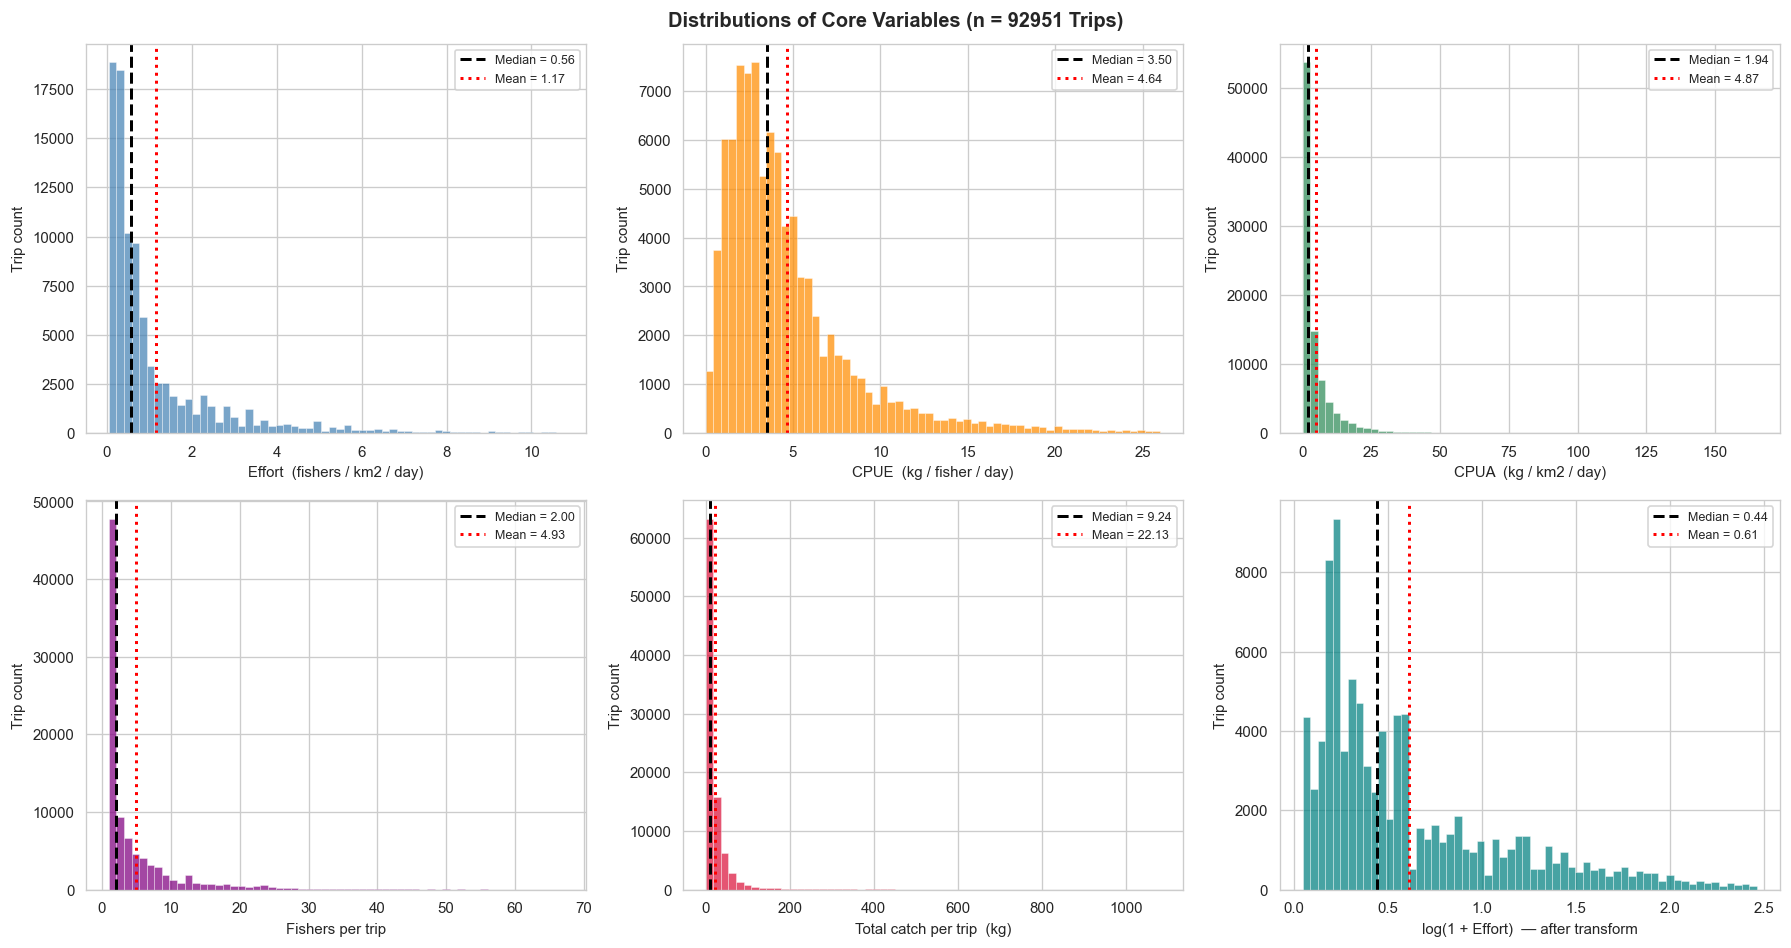

In [16]:
# ─── CELL 2-B  Distribution histograms for core variables 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Distributions of Core Variables (n = {TOTAL_TRIPS} Trips)',
             fontsize=12, fontweight='bold')

specs = [
    ('effort',         'Effort  (fishers / km2 / day)',   'steelblue'),
    ('cpue',           'CPUE  (kg / fisher / day)',        'darkorange'),
    ('cpua',           'CPUA  (kg / km2 / day)',           'seagreen'),
    ('total_fishers',  'Fishers per trip',                 'purple'),
    ('total_catch_kg', 'Total catch per trip  (kg)',       'crimson'),
    ('log_effort',     'log(1 + Effort)  — after transform','teal'),
]
for ax, (col, label, colour) in zip(axes.flat, specs):
    d = viz_df[col].dropna()
    ax.hist(d, bins=60, color=colour, alpha=0.72, edgecolor='white', linewidth=0.3)
    ax.axvline(d.median(), color='black', lw=1.8, ls='--',
               label=f'Median = {d.median():.2f}')
    ax.axvline(d.mean(),   color='red',   lw=1.8, ls=':',
               label=f'Mean = {d.mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Trip count')
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig(OUT + 'S02_distributions.png', bbox_inches='tight')
plt.show()

### Interpretation of Section 2
| Variable | Median | Mean | Observation |
|----------|--------|------|----------------|
| Effort (fishers/km2/day) | **0.56** | 1.17 | Right-skewed |
| CPUE (kg/fisher/day) | **3.50** | 4.64 | Right-skewed |
| Catch per trip (kg) | **9.24** | 22.13 | Very heavily skewed |
| log(1+Effort) | 0.44 | 0.61 | Approximately symmetric after transform |

Both effort and CPUE are right-skewed, and the log transform produces approximately symmetric distributions

### Action
I will use **log-transformed variables** in all regression and correlation analysis
The median is as important as the mean throughout because of the skew


---
## Section 3 — The Core Effort-CPUE Relationship

### Rationale
So the question: **does higher effort mean lower catch per fisher?**

To answer it, we need to view:
- **LOWESS** (locally weighted smoother) | reveals the empirical shape with zero assumptions
- **Binned means** with ±2 SE bands | shows average CPUE at each effort level with uncertainty
- **Log-log OLS** | estimates the power-law constant-elasticity slope


In [17]:
# ─── CELL 3-A  Overall correlation and log-log slope 
rho_all, p_all = spearmanr(viz_df['effort'], viz_df['cpue'])
sl_log, ic_log, r_log, p_log, _ = stats.linregress(
    viz_df['log_effort'], viz_df['log_cpue'])

print(f'Overall Spearman rho (effort vs CPUE):  {rho_all:.4f}  (p = {p_all:.2e})')
print(f'Log-log OLS slope:                      {sl_log:.4f}  (r = {r_log:.3f}, p = {p_log:.2e})')
print()
print('Interpretation:')
print(f'  rho = {rho_all:.4f}  ->  more effort is weakly but significantly associated with LOWER CPUE')
print(f'  log-log slope = {sl_log:.4f}  ->  doubling effort associates with ~{abs(sl_log)*np.log(2)*100:.1f}% lower CPUE (raw, biased)')
print()
print('  NOTE: This raw signal UNDERESTIMATES the true causal effect.')
print('  Selection bias pushes the correlation toward zero.')
print('  Fixed Effects in Phase 3 will remove this bias and reveal the true magnitude.')

Overall Spearman rho (effort vs CPUE):  -0.0804  (p = 4.83e-133)
Log-log OLS slope:                      -0.1038  (r = -0.090, p = 1.13e-165)

Interpretation:
  rho = -0.0804  ->  more effort is weakly but significantly associated with LOWER CPUE
  log-log slope = -0.1038  ->  doubling effort associates with ~7.2% lower CPUE (raw, biased)

  NOTE: This raw signal UNDERESTIMATES the true causal effect.
  Selection bias pushes the correlation toward zero.
  Fixed Effects in Phase 3 will remove this bias and reveal the true magnitude.


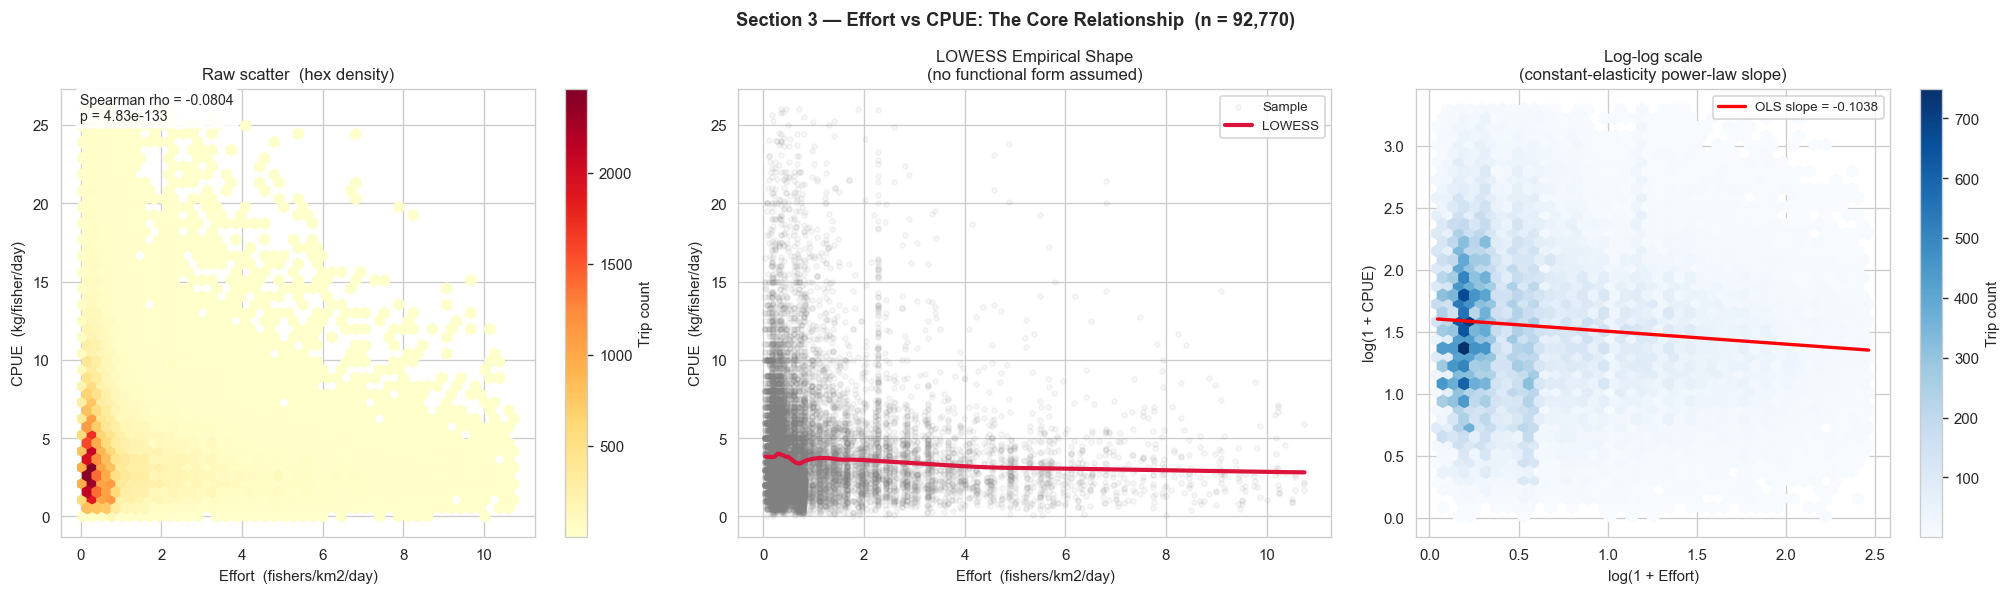

In [18]:
# ─── CELL 3-B  Three-panel core relationship chart 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Section 3 — Effort vs CPUE: The Core Relationship  (n = 92,770)',
             fontsize=11, fontweight='bold')

# Panel A: hex-density scatter
ax = axes[0]
hb = ax.hexbin(viz_df['effort'], viz_df['cpue'], gridsize=45, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Trip count')
ax.set_xlabel('Effort  (fishers/km2/day)')
ax.set_ylabel('CPUE  (kg/fisher/day)')
ax.set_title('Raw scatter  (hex density)')
ax.text(0.04, 0.93,
        f'Spearman rho = {rho_all:.4f}\np = {p_all:.2e}',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# Panel B: LOWESS — the honest empirical shape with no assumptions imposed
ax = axes[1]
samp = viz_df.sample(n=12000, random_state=42)
ax.scatter(samp['effort'], samp['cpue'], alpha=0.07, color='gray', s=10, label='Sample')
lowess_out = sm.nonparametric.lowess(samp['cpue'], samp['effort'], frac=0.3)
ax.plot(lowess_out[:,0], lowess_out[:,1], color='crimson', lw=2.5, label='LOWESS')
ax.set_xlabel('Effort  (fishers/km2/day)')
ax.set_ylabel('CPUE  (kg/fisher/day)')
ax.set_title('LOWESS Empirical Shape\n(no functional form assumed)')
ax.legend(fontsize=8)

# Panel C: log-log scatter with OLS line
ax = axes[2]
hb2 = ax.hexbin(viz_df['log_effort'], viz_df['log_cpue'],
                gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(hb2, ax=ax, label='Trip count')
xr = np.linspace(viz_df['log_effort'].min(), viz_df['log_effort'].max(), 100)
ax.plot(xr, sl_log*xr + ic_log, 'r-', lw=2, label=f'OLS slope = {sl_log:.4f}')
ax.set_xlabel('log(1 + Effort)')
ax.set_ylabel('log(1 + CPUE)')
ax.set_title('Log-log scale\n(constant-elasticity power-law slope)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT + 'S03a_core_relationship.png', bbox_inches='tight')
plt.show()

Interpretation:
There is a real but weak negative relationship between effort (fisher density) and CPUE (individual productivity) in the raw data, so:
- when effort increases, CPUE tends to decrease on average
- but the relationship is noisy / highly heterogeneous
- so effort is not the only driver of CPUE (which you already suspected)

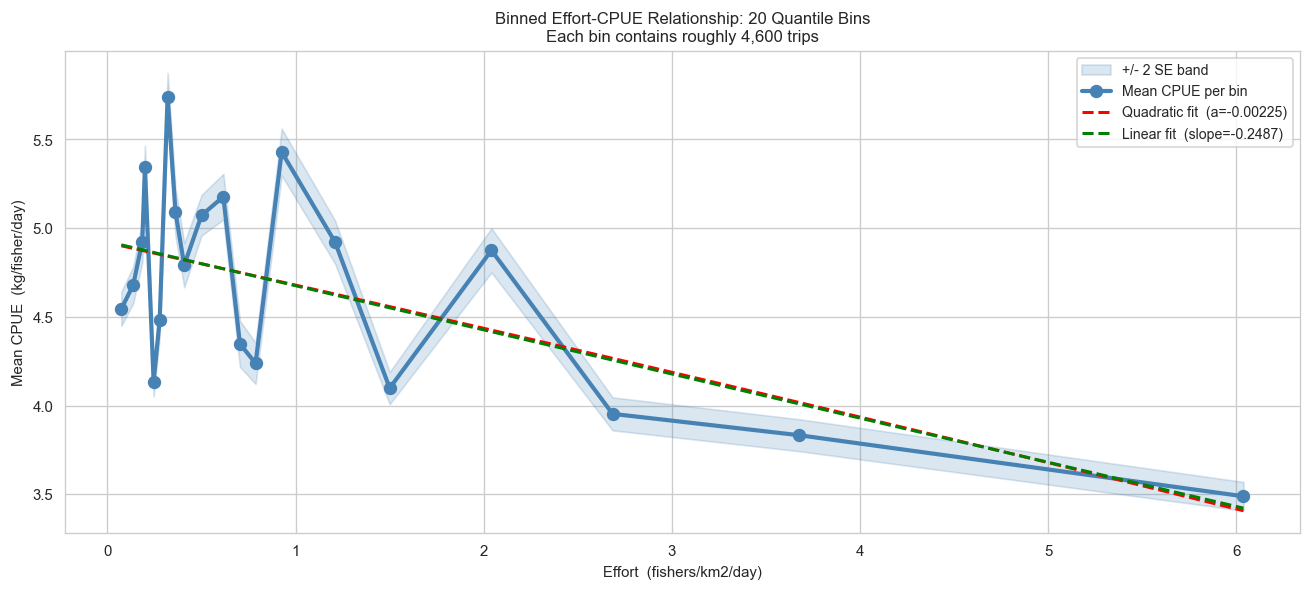

Quadratic term a = -0.00225
  Negative => CPUE declines at an accelerating rate at high effort
  Consistent with diminishing returns / approaching depletion threshold


In [19]:
# ─── CELL 3-C  Binned means — 20 quantile bins with uncertainty bands

viz_df['ebin'] = pd.qcut(viz_df['effort'], q=20, labels=False, duplicates='drop')
binned = viz_df.groupby('ebin').agg(
    effort_mid=('effort', 'median'),
    cpue_mean =('cpue',   'mean'),
    cpue_se   =('cpue',   lambda x: x.std() / np.sqrt(len(x))),
    n         =('cpue',   'size')
).reset_index()

coef2 = np.polyfit(binned['effort_mid'], binned['cpue_mean'], 2, w=np.sqrt(binned['n']))
coef1 = np.polyfit(binned['effort_mid'], binned['cpue_mean'], 1, w=np.sqrt(binned['n']))

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(binned['effort_mid'],
                binned['cpue_mean'] - 2*binned['cpue_se'],
                binned['cpue_mean'] + 2*binned['cpue_se'],
                alpha=0.20, color='steelblue', label='+/- 2 SE band')
ax.plot(binned['effort_mid'], binned['cpue_mean'], 'o-',
        color='steelblue', lw=2.5, ms=7, label='Mean CPUE per bin')

xfit = np.linspace(binned['effort_mid'].min(), binned['effort_mid'].max(), 200)
ax.plot(xfit, np.poly1d(coef2)(xfit), 'r--', lw=1.8,
        label=f'Quadratic fit  (a={coef2[0]:+.5f})')
ax.plot(xfit, np.poly1d(coef1)(xfit), 'g--', lw=1.8,
        label=f'Linear fit  (slope={coef1[0]:+.4f})')

ax.set_xlabel('Effort  (fishers/km2/day)')
ax.set_ylabel('Mean CPUE  (kg/fisher/day)')
ax.set_title('Binned Effort-CPUE Relationship: 20 Quantile Bins\n'
             'Each bin contains roughly 4,600 trips')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(OUT + 'S03b_binned_means.png', bbox_inches='tight')
plt.show()

print(f'Quadratic term a = {coef2[0]:+.5f}')
if coef2[0] < 0:
    print('  Negative => CPUE declines at an accelerating rate at high effort')
    print('  Consistent with diminishing returns / approaching depletion threshold')
else:
    print('  Near-zero => relationship is approximately log-linear throughout')

### Interpretation of Section 3
- **Spearman rho = -0.081** (p = 4.8×10⁻¹³3) — weak but statistically certain negative relationship
- **Log-log slope = -0.104** — doubling effort is associated with ~7% lower CPUE in the raw data
- **LOWESS shape**: monotonic, gradually declining — no sharp hump or threshold collapse in the aggregate
- **Quadratic term a = -0.00225** — slightly negative, meaning CPUE declines at an accelerating rate  
  at very high effort, consistent with a depletion dynamic beginning to emerge

The raw correlation **is -0.081 (weak)** because of the selection bias. Fishers preferentially go out during productive seasons  
and to productive areas. So, the -0.081 is not the causal elasticity, where the fixed Effects will reveal the true magnitude

---
## Section 4 — Endogeneity Check via Seasonal Patterns

### Rationale
The endogeneity problem is visible in seasonal analysis
Fishers fish **more** when fish are abundant (high CPUE seasons) and **less** when conditions are poor (low CPUE seasons) 
This creates a **positive co-movement** of effort and CPUE across seasons (the selection bias)

Finding this co-movement is direct empirical proof that season must be a **control variable** in any causal model, or the effort-CPUE estimate will be biased toward zero


In [20]:
# ─── CELL 4-A  Seasonal summary statistics
seasonal = (
    viz_df.groupby('season')
    .agg(cpue_mean=('cpue','mean'), effort_mean=('effort','mean'), n=('cpue','size'))
    .round(3)
    .reset_index()
    .sort_values('cpue_mean', ascending=False)
)

monthly = (
    viz_df.groupby('month')
    .agg(cpue_mean=('cpue','mean'), effort_mean=('effort','mean'))
    .reset_index()
)
monthly_corr = monthly['cpue_mean'].corr(monthly['effort_mean'])

print('Seasonal averages:')
print(f'{"Season":<28} {"CPUE":>8} {"Effort":>8} {"n trips":>9}')
print('-' * 57)
for _, r in seasonal.iterrows():
    print(f'{r["season"]:<28} {r["cpue_mean"]:>8.3f} {r["effort_mean"]:>8.3f} {r["n"]:>9,}')
print()
print(f'Monthly mean CPUE-Effort correlation: r = {monthly_corr:.3f}')
print('  A positive r confirms fishers track fish abundance (endogeneity confirmed)')

Seasonal averages:
Season                           CPUE   Effort   n trips
---------------------------------------------------------
Short Rains (OND)               5.153    1.183    25,486
NE Monsoon (JF)                 5.016    1.287    13,388
Long Rains (MAM)                4.791    1.187    21,646
SE Monsoon (JJAS)               3.984    1.088    32,431

Monthly mean CPUE-Effort correlation: r = 0.753
  A positive r confirms fishers track fish abundance (endogeneity confirmed)


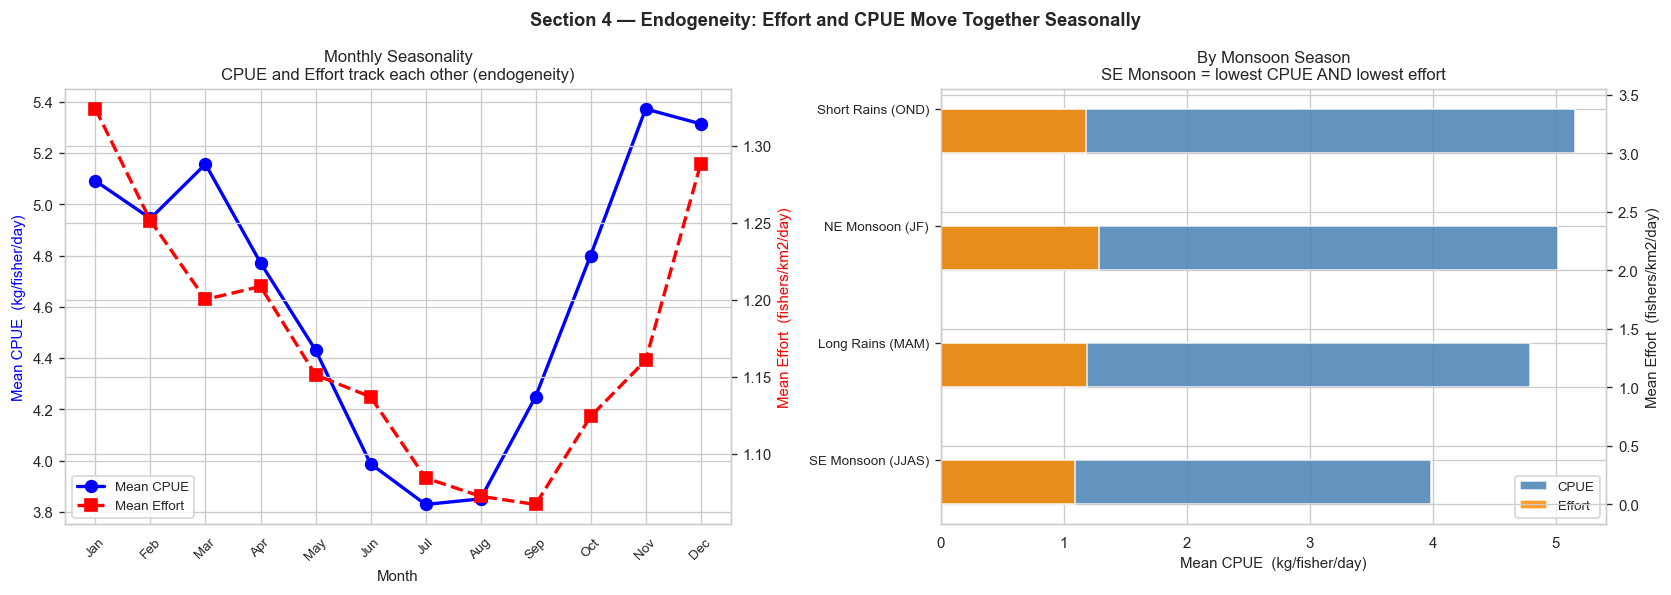

In [21]:
# ─── CELL 4-B  Seasonal visualisation
mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4 — Endogeneity: Effort and CPUE Move Together Seasonally',
             fontsize=11, fontweight='bold')

# Panel A: dual-axis monthly chart — the key endogeneity diagnostic
ax1 = axes[0]
ax2 = ax1.twinx()
l1, = ax1.plot(monthly['month'], monthly['cpue_mean'],   'bo-', lw=2, ms=7, label='Mean CPUE')
l2, = ax2.plot(monthly['month'], monthly['effort_mean'], 'rs--', lw=2, ms=7, label='Mean Effort')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(mn, rotation=45, fontsize=8)
ax1.set_xlabel('Month')
ax1.set_ylabel('Mean CPUE  (kg/fisher/day)', color='blue')
ax2.set_ylabel('Mean Effort  (fishers/km2/day)', color='red')
ax1.set_title('Monthly Seasonality\nCPUE and Effort track each other (endogeneity)')
ax1.legend(handles=[l1, l2], fontsize=8, loc='lower left')

# Panel B: bar chart by monsoon season
ax = axes[1]
s_ord = seasonal.sort_values('cpue_mean', ascending=True)
y = np.arange(len(s_ord))
w = 0.38
b1 = ax.barh(y - w/2, s_ord['cpue_mean'],   w, color='steelblue',  alpha=0.85, label='CPUE')
ax2b = ax.twinx()
b2 = ax2b.barh(y + w/2, s_ord['effort_mean'], w, color='darkorange', alpha=0.85, label='Effort')
ax.set_yticks(y)
ax.set_yticklabels(s_ord['season'], fontsize=8)
ax.set_xlabel('Mean CPUE  (kg/fisher/day)')
ax2b.set_ylabel('Mean Effort  (fishers/km2/day)')
ax.set_title('By Monsoon Season\nSE Monsoon = lowest CPUE AND lowest effort')
ax.legend(handles=[b1, b2], fontsize=8)

plt.tight_layout()
plt.savefig(OUT + 'S04_seasonality.png', bbox_inches='tight')
plt.show()

### Interpretation of Section 4
| Season | CPUE | Effort | Pattern |
|--------|------|--------|--------|
| Short Rains (OND) | **5.15** | 1.18 | Highest CPUE |
| NE Monsoon (JF) | **5.02** | 1.29 | Second highest CPUE |
| Long Rains (MAM) | 4.79 | 1.19 | Moderate both |
| SE Monsoon (JJAS) | **3.98** | **1.09** | Lowest CPUE AND lowest effort |

**Monthly CPUE-Effort correlation = +0.75** — very strong positive co-movement 
This is the endogeneity mechanism made visible in the data

Thus, season **must be a control variable** in all causal models, otherwise the estimate will be biased toward zero


---
## Section 5 — Long-Term Temporal Trends  (2000–2024)

### Rationale
A 30-year dataset lets us detect **stock-level changes** that are invisible in cross-sectional analysis.  
Key questions:
- Is average CPUE rising (recovery) or falling (stock depletion)?
- Is average effort rising (increasing pressure) or falling (management working)?

Year must be a **Year Fixed Effect** in the causal model to prevent long-run trends  
from confounding the effort-CPUE coefficient.  
Without it, the declining effort trend over time would bias the estimate toward zero.


In [22]:
# ─── CELL 5-A  Annual aggregates and OLS trend tests (2000-2024) ──────────────
#
# Use valid_df (not viz_df) so we include all years without winsorisation artefacts
#
annual = (
    valid_df[(valid_df['year'] >= 2000) & (valid_df['year'] <= 2024)]
    .groupby('year')
    .agg(cpue_mean  =('cpue',   'mean'),
         effort_mean=('effort', 'mean'),
         n_trips    =('cpue',   'size'))
    .reset_index()
)

sc, ic_c, rc, pc, _ = stats.linregress(annual['year'], annual['cpue_mean'])
se, ic_e, re, pe, _ = stats.linregress(annual['year'], annual['effort_mean'])

print('Annual trend analysis (2000-2024):')
print(f'  CPUE   trend: {sc:+.4f} kg/fisher/day per year   (r = {rc:.3f}, p = {pc:.4f})')
print(f'  Effort trend: {se:+.4f} fishers/km2/day per year  (r = {re:.3f}, p = {pe:.4f})')
print()
if sc > 0 and pc < 0.05:
    print('  => CPUE is SIGNIFICANTLY RISING over time')
    print('     The aggregate system appears to be recovering at the fleet level')
if se < 0 and pe < 0.05:
    print('  => Effort is SIGNIFICANTLY FALLING over time')
    print('     Aggregate fishing pressure has been decreasing')


Annual trend analysis (2000-2024):
  CPUE   trend: +0.0802 kg/fisher/day per year   (r = 0.831, p = 0.0000)
  Effort trend: -0.0443 fishers/km2/day per year  (r = -0.450, p = 0.0240)

  => CPUE is SIGNIFICANTLY RISING over time
     The aggregate system appears to be recovering at the fleet level
  => Effort is SIGNIFICANTLY FALLING over time
     Aggregate fishing pressure has been decreasing


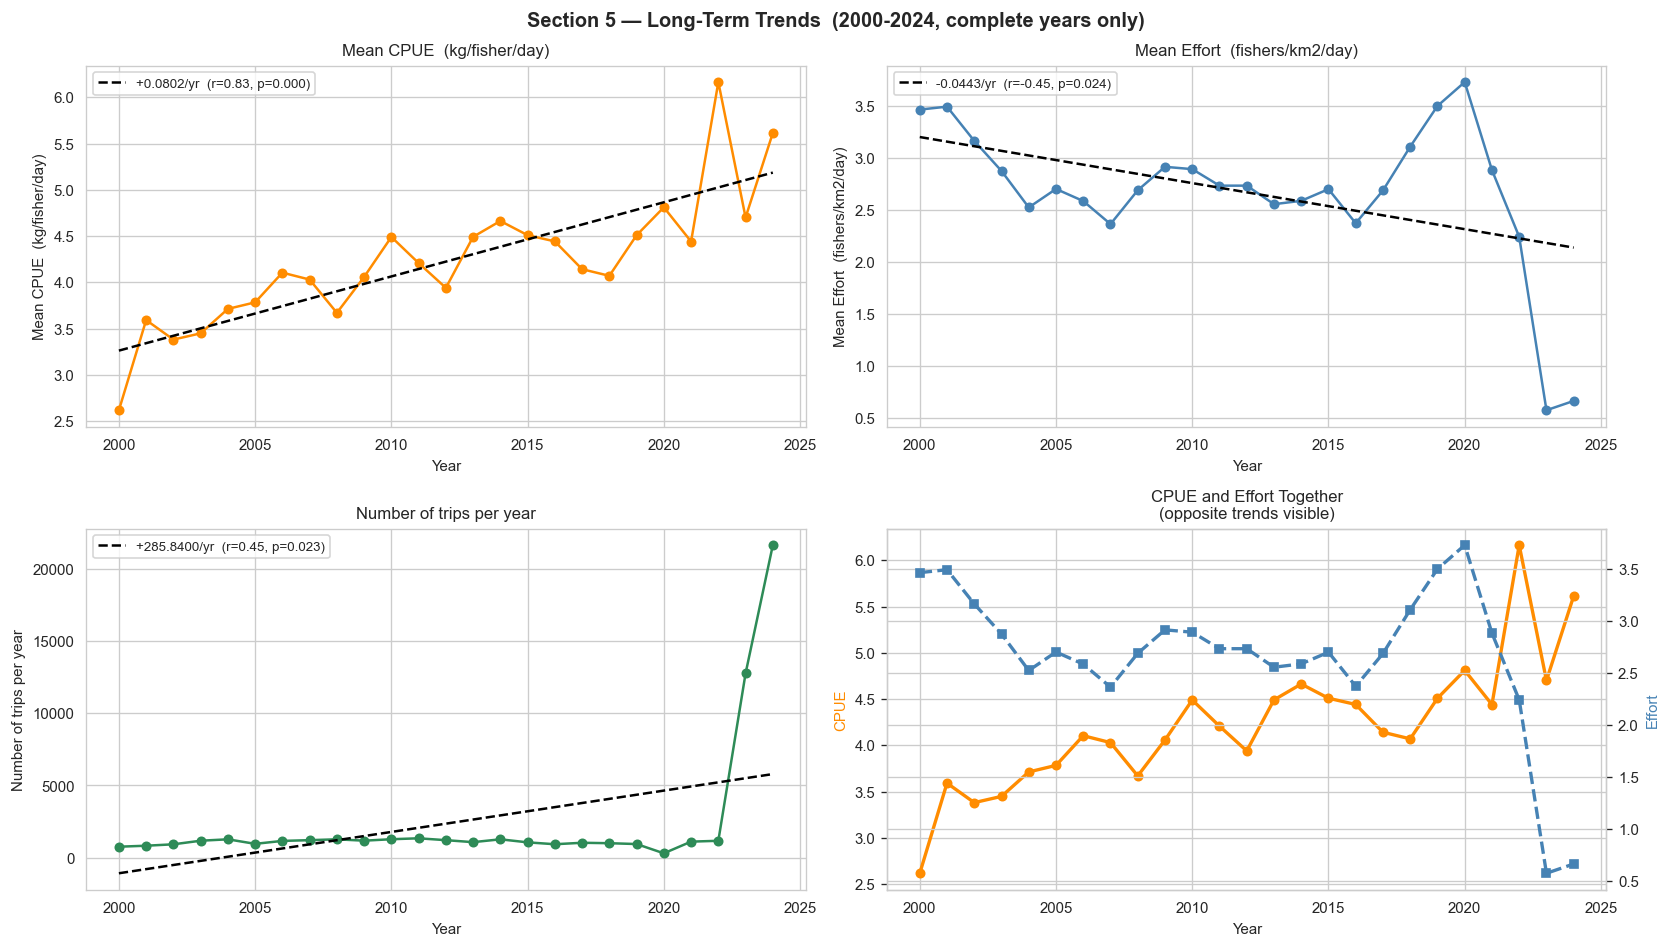

In [23]:
# ─── CELL 5-B  Time-series charts 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Section 5 — Long-Term Trends  (2000-2024, complete years only)',
             fontsize=12, fontweight='bold')

for ax, (col, lbl, colour) in zip(axes.flat[:3], [
    ('cpue_mean',   'Mean CPUE  (kg/fisher/day)',    'darkorange'),
    ('effort_mean', 'Mean Effort  (fishers/km2/day)', 'steelblue'),
    ('n_trips',     'Number of trips per year',       'seagreen'),
]):
    ax.plot(annual['year'], annual[col], 'o-', color=colour, ms=5)
    sl2, ic2, rv2, pv2, _ = stats.linregress(annual['year'], annual[col])
    xr2 = np.linspace(annual['year'].min(), annual['year'].max(), 100)
    ax.plot(xr2, sl2*xr2 + ic2, '--', color='black', lw=1.5,
            label=f'{sl2:+.4f}/yr  (r={rv2:.2f}, p={pv2:.3f})')
    ax.set_xlabel('Year')
    ax.set_ylabel(lbl)
    ax.set_title(lbl)
    ax.legend(fontsize=8)

# Dual-axis CPUE vs Effort together
ax = axes[1,1]
ax2t = ax.twinx()
ax.plot(annual['year'],  annual['cpue_mean'],   'o-', color='darkorange', lw=2, ms=5, label='CPUE')
ax2t.plot(annual['year'], annual['effort_mean'], 's--', color='steelblue',  lw=2, ms=5, label='Effort')
ax.set_ylabel('CPUE', color='darkorange')
ax2t.set_ylabel('Effort', color='steelblue')
ax.set_title('CPUE and Effort Together\n(opposite trends visible)')
ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig(OUT + 'S05_temporal_trends.png', bbox_inches='tight')
plt.show()

### Interpretation of Section 5
- **CPUE trend: +0.080/yr** (r = 0.83, p < 0.000) | catch rates have been **significantly rising** since 2000
- **Effort trend: -0.044/yr** (r = -0.450, p = 0.024) | aggregate fishing pressure has been **falling**

The aggregate story is positive — less effort, more catch per fisher 
But this masks large heterogeneity:  
**Depleting BMUs** (majoreni: -0.110/yr, bureni: -0.116/yr, shimoni: -0.929/yr)  
**Recovering BMUs** (wasini: +1.699/yr, mkwiro: +0.845/yr, kijangwani: +0.257/yr)

Thus, **Year is a Fixed Effect** in the causal modeling


---
## Section 6 — Effort-CPUE Relationship by Gear Type

### Rationale
Different gears target different species, operate at different depths, and interact with the ecosystem in different ways. Pooling all gears into one relationship is not correct

For each gear, I compute:
- **Spearman rho** — direction and strength of effort-CPUE correlation
- **Depletion ratio** — CPUE at high effort (Q3) divided by CPUE at low effort (Q1).  (Values below 1.0 mean crowded fishing is less productive per fisher)
- **Log-log slope** — constant-elasticity: how many % does CPUE change per 1% change in effort?


In [24]:
# ─── CELL 6-A  Compute all gear statistics
gear_stats = []
for g in GEARS:
    s = viz_df[viz_df['gear'] == g]
    if len(s) < 30:
        continue
    rho_g, pv_g = spearmanr(s['effort'], s['cpue'])
    lo_e, hi_e  = s['effort'].quantile([0.25, 0.75])
    cpue_lo = s[s['effort'] <= lo_e]['cpue'].mean()
    cpue_hi = s[s['effort'] >= hi_e]['cpue'].mean()
    sl_g, _, _, _, _ = stats.linregress(s['log_effort'], s['log_cpue'])
    gear_stats.append({
        'gear':       g,
        'n':          len(s),
        'effort_med': round(s['effort'].median(), 3),
        'cpue_med':   round(s['cpue'].median(),   3),
        'cpue_mean':  round(s['cpue'].mean(),      3),
        'rho':        round(rho_g, 4),
        'pval':       pv_g,
        'sig':        sig_stars(pv_g),
        'depl_ratio': round(cpue_hi / cpue_lo, 3) if cpue_lo > 0 else np.nan,
        'log_slope':  round(sl_g, 4),
    })
gear_df = pd.DataFrame(gear_stats).sort_values('rho').reset_index(drop=True)

print('GEAR ANALYSIS RESULTS')
print('=' * 98)
print(f'{"Gear":<16} {"n":>7} {"Eff_med":>8} {"CPUE_med":>9}'
      f' {"rho":>8} {"Sig":>5} {"Depl_ratio":>11} {"LogSlope":>9}')
print('-' * 98)
for _, r in gear_df.iterrows():
    flag = '  << STRONG depletion'   if r['depl_ratio'] < 0.70 else (
           '  < moderate depletion'  if r['depl_ratio'] <= 0.90 else (
           '  (no depletion signal)' if r['depl_ratio'] >= 1.00 else ''))
    print(f'{r["gear"]:<16} {r["n"]:>7,} {r["effort_med"]:>8.3f} {r["cpue_med"]:>9.3f}'
          f' {r["rho"]:>8.4f} {r["sig"]:>5} {r["depl_ratio"]:>11.3f} {r["log_slope"]:>9.4f}{flag}')

GEAR ANALYSIS RESULTS
Gear                   n  Eff_med  CPUE_med      rho   Sig  Depl_ratio  LogSlope
--------------------------------------------------------------------------------------------------
nets              28,057    1.000     3.500  -0.1129   ***       0.658   -0.1566  << STRONG depletion
handline          10,981    0.495     3.552  -0.1103   ***       0.845   -0.1777  < moderate depletion
fencetrap            181    0.143     2.667  -0.0943    ns       1.070    0.0351  (no depletion signal)
traps             18,551    0.358     3.750  -0.0876   ***       0.842   -0.2169  < moderate depletion
hook and stick    18,509    0.278     3.500  -0.0812   ***       0.862   -0.3268  < moderate depletion
longline             184    0.406     7.798  -0.0453    ns       1.055   -0.1127  (no depletion signal)
none                 181    0.556     4.200   0.0193    ns       1.203   -0.1050  (no depletion signal)
speargun          15,729    1.085     3.390   0.0228    **       0.929    0

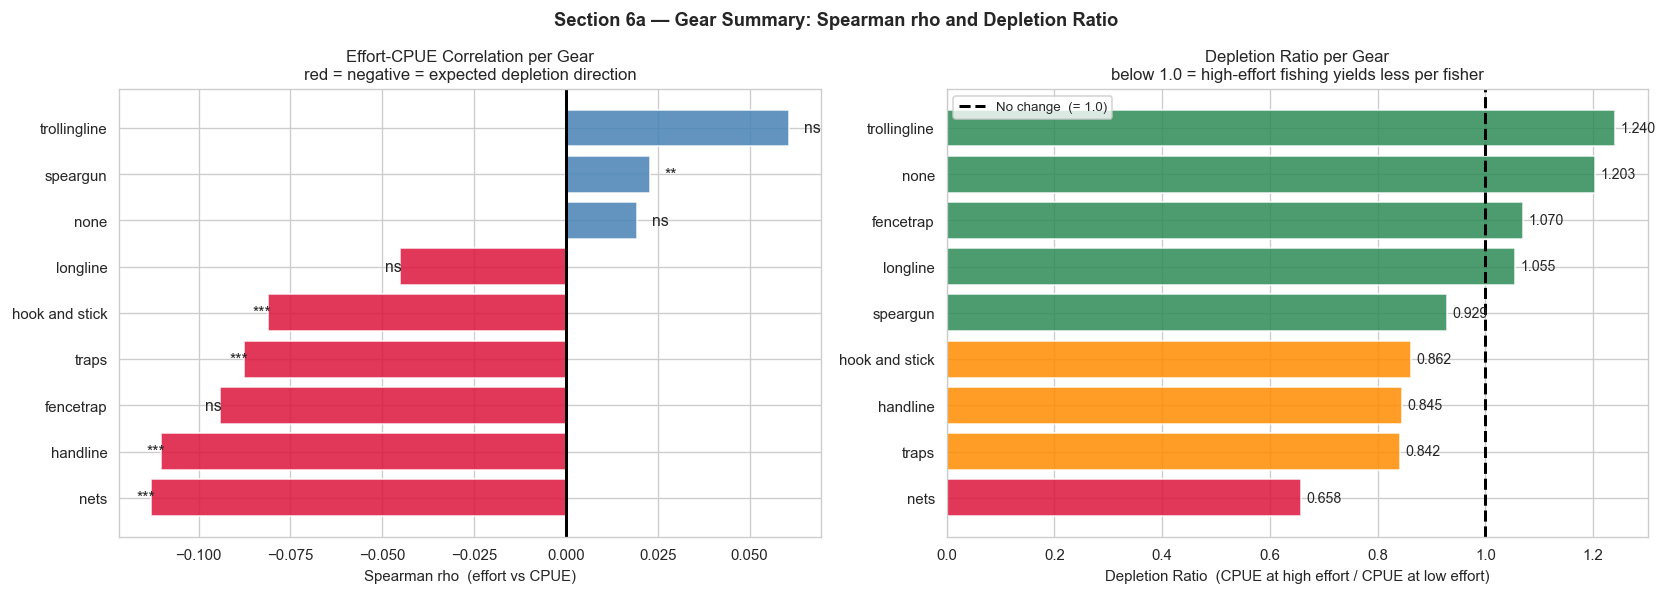

In [25]:
# ─── CELL 6-B  Gear summary charts: correlation and depletion ratio 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 6a — Gear Summary: Spearman rho and Depletion Ratio',
             fontsize=11, fontweight='bold')

# Spearman rho bars
ax = axes[0]
gd = gear_df.sort_values('rho')
bar_cols = ['crimson' if r < 0 else 'steelblue' for r in gd['rho']]
bars = ax.barh(gd['gear'], gd['rho'], color=bar_cols, alpha=0.85)
ax.axvline(0, color='black', lw=1.8)
for bar, sg in zip(bars, gd['sig']):
    x = bar.get_width()
    ax.text(x + 0.004 if x >= 0 else x - 0.004,
            bar.get_y() + bar.get_height()/2, sg, va='center', fontsize=9.5)
ax.set_xlabel('Spearman rho  (effort vs CPUE)')
ax.set_title('Effort-CPUE Correlation per Gear\nred = negative = expected depletion direction')

# Depletion ratio bars
ax = axes[1]
gd2 = gear_df.sort_values('depl_ratio')
bar_cols2 = ['crimson'    if v < 0.70 else
             'darkorange' if v < 0.90 else
             'seagreen'
             for v in gd2['depl_ratio']]
bars2 = ax.barh(gd2['gear'], gd2['depl_ratio'], color=bar_cols2, alpha=0.85)
ax.axvline(1.0, color='black', lw=1.8, ls='--', label='No change  (= 1.0)')
for bar, val in zip(bars2, gd2['depl_ratio']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)
ax.set_xlabel('Depletion Ratio  (CPUE at high effort / CPUE at low effort)')
ax.set_title('Depletion Ratio per Gear\nbelow 1.0 = high-effort fishing yields less per fisher')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT + 'S06a_gear_summary.png', bbox_inches='tight')
plt.show()

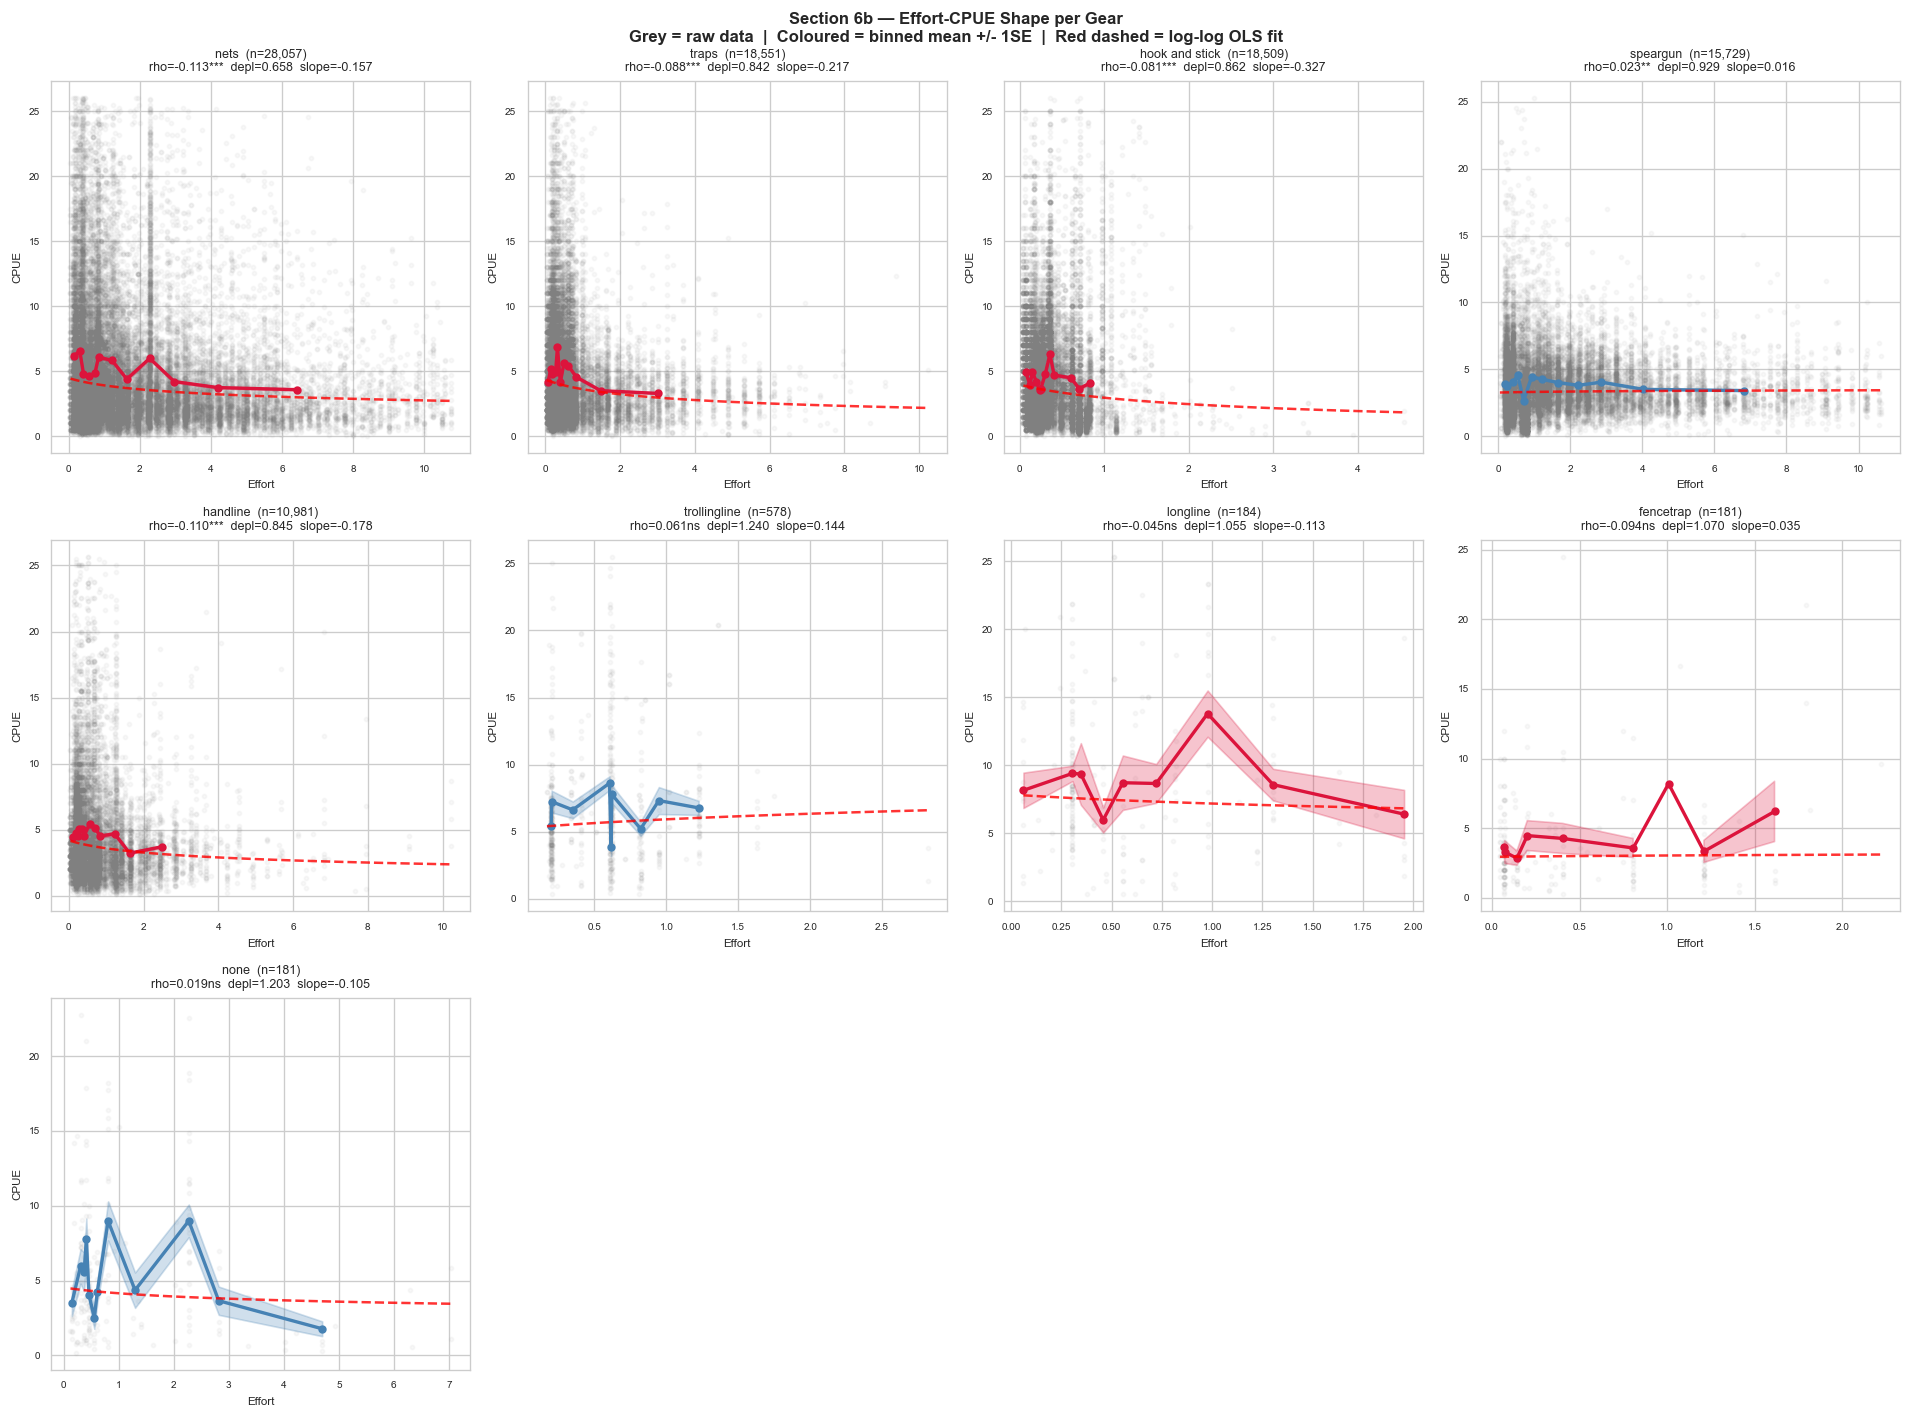

In [26]:
# ─── CELL 6-C  Small multiples — one binned-curve panel per gear 
#
# grey dots: raw data (sparse sample)
# coloured line: binned mean +/- 1 SE  (red if rho<0, blue if rho>0)
# red dashed: back-transformed log-log OLS fit
#
n_cols = 4
n_rows = int(np.ceil(len(GEARS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
fig.suptitle('Section 6b — Effort-CPUE Shape per Gear\n'
             'Grey = raw data  |  Coloured = binned mean +/- 1SE  |  Red dashed = log-log OLS fit',
             fontsize=10, fontweight='bold')

for ax, g in zip(axes.flat, GEARS):
    s = viz_df[viz_df['gear'] == g].copy()
    row_g = gear_df[gear_df['gear'] == g]
    if row_g.empty or len(s) < 50:
        ax.set_title(f'{g}  (n={len(s)}, skip)')
        continue
    row_g = row_g.iloc[0]

    ax.scatter(s['effort'], s['cpue'], alpha=0.05, s=6, color='gray', zorder=1)

    s['eb'] = pd.qcut(s['effort'], q=min(12, s['effort'].nunique()),
                      labels=False, duplicates='drop')
    b = s.groupby('eb').agg(
        em=('effort','median'),
        cm=('cpue',  'mean'),
        se=('cpue',  lambda x: x.std() / np.sqrt(len(x))))
    col = 'crimson' if row_g['rho'] < 0 else 'steelblue'
    ax.fill_between(b['em'], b['cm'] - b['se'], b['cm'] + b['se'],
                    alpha=0.25, color=col, zorder=2)
    ax.plot(b['em'], b['cm'], 'o-', color=col, lw=2, ms=4, zorder=3)

    sl2, ic2, _, _, _ = stats.linregress(s['log_effort'], s['log_cpue'])
    xrng = np.linspace(s['log_effort'].min(), s['log_effort'].max(), 100)
    ax.plot(np.expm1(xrng), np.expm1(sl2*xrng + ic2), 'r--', lw=1.5, alpha=0.8, zorder=4)

    ax.set_title(
        f'{g}  (n={len(s):,})\n'
        f'rho={row_g["rho"]:.3f}{row_g["sig"]}  '
        f'depl={row_g["depl_ratio"]:.3f}  '
        f'slope={row_g["log_slope"]:.3f}',
        fontsize=7.5)
    ax.set_xlabel('Effort', fontsize=7)
    ax.set_ylabel('CPUE',   fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(GEARS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(OUT + 'S06b_gear_multiples.png', bbox_inches='tight')
plt.show()

### Interpretation for Section 6

| Gear | n | rho | Sig | Depletion Ratio | Verdict |
|------|---|-----|-----|-----------------|---------|
| **nets** | 28,057 | **-0.113** | *** | **0.658** | STRONGEST signal: CPUE drops 34% at high effort |
| handline | 10,981 | -0.110 | *** | 0.845 | Moderate depletion |
| traps | 18,551 | -0.088 | *** | 0.842 | Moderate depletion |
| hook & stick | 18,509 | -0.081 | *** | 0.862 | Moderate depletion |
| **speargun** | 15,729 | +0.023 | ** | 0.929 | **No depletion** |
| trollingline | 578 | +0.061 | ns | 1.240 | **No depletion** |

**Key findings:**
- The four gears (nets, handline, traps, hook & stick) show the depletion pattern  
- Nets have the strongest signal: depletion ratio = 0.658 means **34% lower CPUE** when effort is in the top 25% vs the bottom 25%

Thus, need to build **separate causal models** for depletion gears (nets, handline, traps, hook & stick) and no depletion gears (speargun and trollingline)

---
## Section 7 — Effort-CPUE Relationship by BMU

Testing the effort-CPUE relationship **within each BMU** and also tracking the **CPUE trend over time** for each BMU

Two analysis to understand this relationship:
- **Spearman rho**: does higher effort within this BMU mean lower CPUE?
- **CPUE trend/yr**: is productivity rising or falling over the years?


In [27]:
# ─── CELL 7-A  Per-BMU statistics
bmu_stats = []
for b in BMUS:
    s = viz_df[viz_df['BMU'] == b]
    if len(s) < 30:
        continue
    rho_b, pv_b = spearmanr(s['effort'], s['cpue'])
    lo_e, hi_e  = s['effort'].quantile([0.25, 0.75])
    cpue_lo = s[s['effort'] <= lo_e]['cpue'].mean()
    cpue_hi = s[s['effort'] >= hi_e]['cpue'].mean()
    syr     = stats.linregress(s['year'], s['cpue'])[0] if s['year'].nunique() > 2 else np.nan
    cv      = s['effort'].std() / s['effort'].mean()
    bmu_stats.append({
        'BMU':        b,
        'n':          len(s),
        'effort_med': round(s['effort'].median(), 3),
        'effort_cv':  round(cv, 3),
        'cpue_mean':  round(s['cpue'].mean(), 3),
        'cpue_med':   round(s['cpue'].median(), 3),
        'rho':        round(rho_b, 4),
        'pval':       pv_b,
        'sig':        sig_stars(pv_b),
        'depl_ratio': round(cpue_hi / cpue_lo, 3) if cpue_lo > 0 else np.nan,
        'cpue_trend': round(syr, 4) if not pd.isna(syr) else np.nan,
        'n_years':    s['year'].nunique(),
    })

bmu_df = pd.DataFrame(bmu_stats).sort_values('rho').reset_index(drop=True)

print(f'BMUs analysed: {len(bmu_df)}')
print(f'  Negative rho (depletion signal):  {(bmu_df["rho"] < 0).sum()}')
print(f'  Positive rho (selection bias):    {(bmu_df["rho"] > 0).sum()}')
print(f'  Statistically significant:        {(bmu_df["pval"] < 0.05).sum()}')
print()
print(f'{"BMU":<20} {"n":>6} {"EffMed":>7} {"CPUE_mn":>8}'
      f' {"rho":>8} {"Sig":>5} {"Trend/yr":>9} {"Yrs":>4}')
print('-' * 72)
for _, r in bmu_df.iterrows():
    tr   = f'{r["cpue_trend"]:+.3f}' if pd.notna(r['cpue_trend']) else '  n/a'
    # Flag: positive rho but declining trend = hidden depletion
    flag = ' !! HIDDEN DEPLETION' if (
        r['rho'] > 0.1 and pd.notna(r['cpue_trend']) and r['cpue_trend'] < -0.05
    ) else ''
    print(f'{r["BMU"]:<20} {r["n"]:>6,} {r["effort_med"]:>7.3f} {r["cpue_mean"]:>8.3f}'
          f' {r["rho"]:>8.4f} {r["sig"]:>5} {tr:>9} {r["n_years"]:>4}{flag}')

BMUs analysed: 31
  Negative rho (depletion signal):  14
  Positive rho (selection bias):    17
  Statistically significant:        25

BMU                       n  EffMed  CPUE_mn      rho   Sig  Trend/yr  Yrs
------------------------------------------------------------------------
majoreni              4,826   0.148    3.051  -0.5646   ***    -0.112    4
marina                1,058   2.250    3.867  -0.3481   ***    +0.095   23
reef                  4,021   0.199    5.072  -0.2482   ***    +0.129   21
kenyatta              9,327   0.833    3.979  -0.1989   ***    +0.043   31
nyali                 5,299   0.500    3.654  -0.1132   ***    +0.014   26
mwaepe                4,536   0.474    3.723  -0.1122   ***    +0.031   31
gazi                  6,202   0.763    5.675  -0.0954   ***    +0.037   24
mvuleni               3,475   0.816    4.030  -0.0912   ***    +0.029   31
shelly_timbwani       1,102   0.248    3.504  -0.0881    **       n/a    1
rigata                3,788   0.185    3.

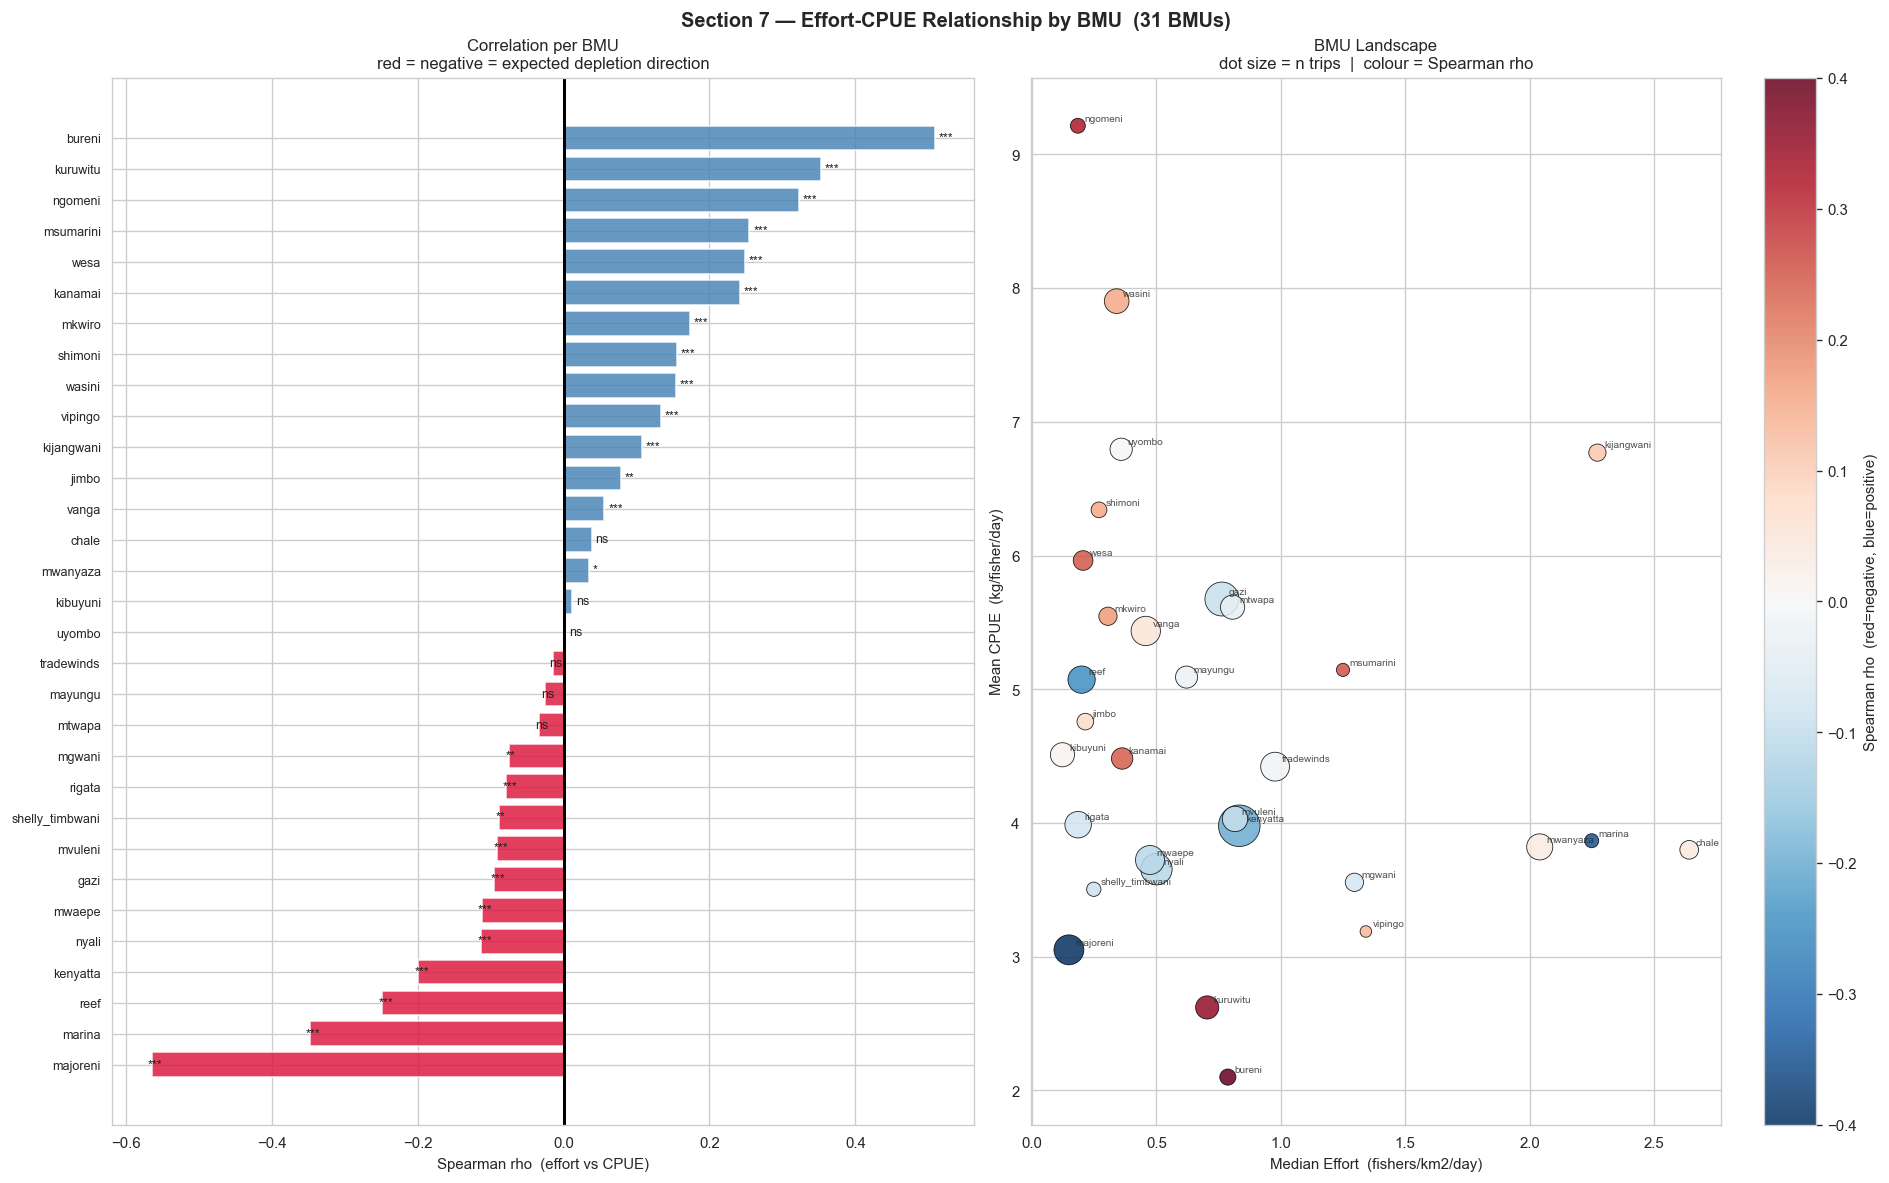

In [28]:
# ─── CELL 7-B  Forest plot + landscape scatter 
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Section 7 — Effort-CPUE Relationship by BMU  (31 BMUs)',
             fontsize=12, fontweight='bold')

# Forest plot: one bar per BMU sorted by rho
ax = axes[0]
bar_cols = ['crimson' if r < 0 else 'steelblue' for r in bmu_df['rho']]
bars = ax.barh(bmu_df['BMU'], bmu_df['rho'], color=bar_cols, alpha=0.82)
ax.axvline(0, color='black', lw=1.8)
for bar, sg in zip(bars, bmu_df['sig']):
    x = bar.get_width()
    ax.text(x + 0.005 if x >= 0 else x - 0.005,
            bar.get_y() + bar.get_height()/2, sg, va='center', fontsize=7.5)
ax.set_xlabel('Spearman rho  (effort vs CPUE)')
ax.set_title('Correlation per BMU\nred = negative = expected depletion direction')
ax.tick_params(axis='y', labelsize=7.5)

# Landscape scatter: median effort vs mean CPUE, colour = rho
ax = axes[1]
sc = ax.scatter(bmu_df['effort_med'], bmu_df['cpue_mean'],
                c=bmu_df['rho'], cmap='RdBu_r', vmin=-0.4, vmax=0.4,
                s=bmu_df['n'] / 15, edgecolors='black', linewidths=0.5, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Spearman rho  (red=negative, blue=positive)')
for _, r in bmu_df.iterrows():
    ax.annotate(r['BMU'], (r['effort_med'], r['cpue_mean']),
                fontsize=6, xytext=(4, 3), textcoords='offset points', alpha=0.8)
ax.set_xlabel('Median Effort  (fishers/km2/day)')
ax.set_ylabel('Mean CPUE  (kg/fisher/day)')
ax.set_title('BMU Landscape\ndot size = n trips  |  colour = Spearman rho')

plt.tight_layout()
plt.savefig(OUT + 'S07a_bmu_forest_landscape.png', bbox_inches='tight')
plt.show()

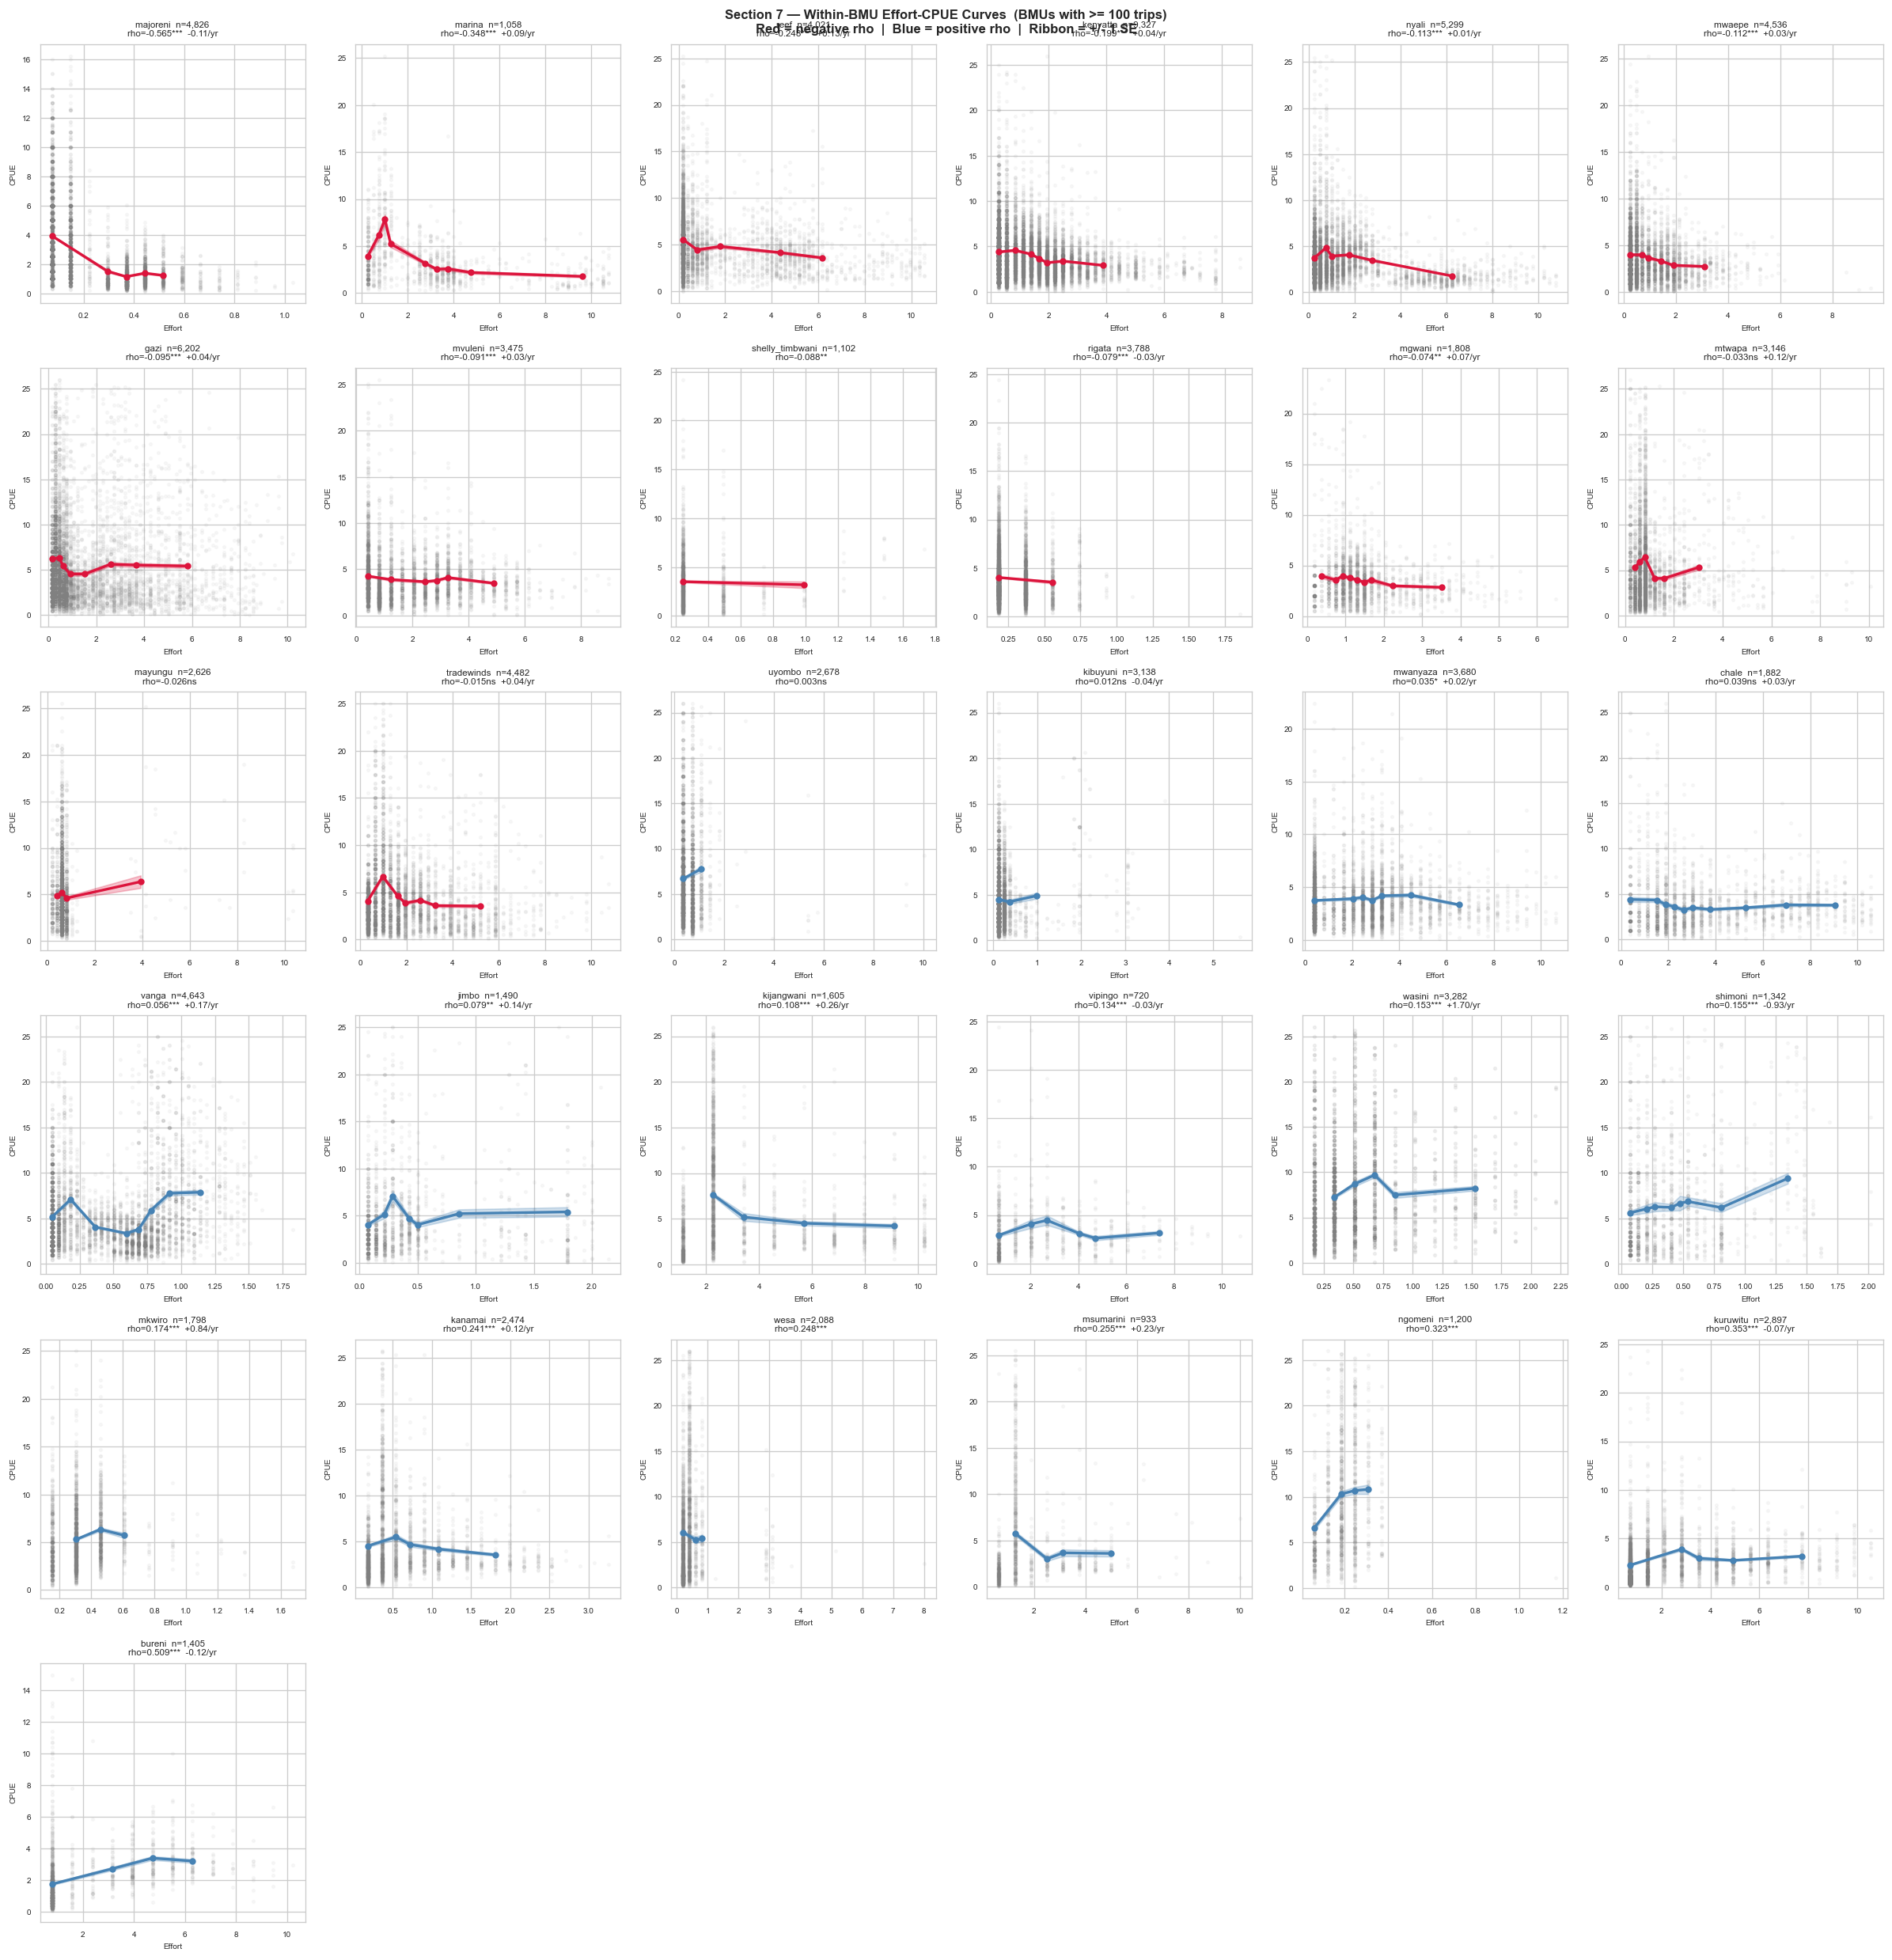

In [29]:
# ─── CELL 7-C  Small multiples — within-BMU effort-CPUE curves
#
# Each panel: grey = raw data | coloured = binned mean +/- 1SE (red if rho<0) | title = stats
#
bmus_plot = bmu_df[bmu_df['n'] >= 100]['BMU'].tolist()
n_cols = 6
n_rows = int(np.ceil(len(bmus_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
fig.suptitle('Section 7 — Within-BMU Effort-CPUE Curves  (BMUs with >= 100 trips)\n'
             'Red = negative rho  |  Blue = positive rho  |  Ribbon = +/- 1 SE',
             fontsize=10, fontweight='bold')

for ax, bmu in zip(axes.flat, bmus_plot):
    s   = viz_df[viz_df['BMU'] == bmu].copy()
    row = bmu_df[bmu_df['BMU'] == bmu].iloc[0]
    s['eb'] = pd.qcut(s['effort'], q=min(10, s['effort'].nunique()),
                      labels=False, duplicates='drop')
    b = s.groupby('eb').agg(
        em=('effort','median'),
        cm=('cpue',  'mean'),
        se=('cpue',  lambda x: x.std() / max(1, np.sqrt(len(x)))))
    col = 'crimson' if row['rho'] < 0 else 'steelblue'
    ax.scatter(s['effort'], s['cpue'], alpha=0.05, s=5, color='gray', zorder=1)
    ax.fill_between(b['em'], b['cm'] - b['se'], b['cm'] + b['se'],
                    alpha=0.25, color=col, zorder=2)
    ax.plot(b['em'], b['cm'], 'o-', color=col, lw=2, ms=4, zorder=3)
    tr = f'{row["cpue_trend"]:+.2f}/yr' if pd.notna(row['cpue_trend']) else ''
    ax.set_title(f'{bmu}  n={len(s):,}\nrho={row["rho"]:.3f}{row["sig"]}  {tr}',
                 fontsize=7)
    ax.set_xlabel('Effort', fontsize=6)
    ax.set_ylabel('CPUE',   fontsize=6)
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(bmus_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(OUT + 'S07b_bmu_curves.png', bbox_inches='tight', dpi=100)
plt.show()

### Interpretation of Section 7

**Summary: 14 negative rho, 17 positive rho, 25/31 statistically significant**

**Clear depletion BMUs** — negative rho confirmed by data volume:
| BMU | rho | CPUE trend/yr | Assessment |
|-----|-----|--------------|------------|
| majoreni | **-0.565** | -0.110 | Most depleted, even low effort is too much |
| marina | -0.348 | +0.094 | Depleting but slight recovery visible |
| reef | -0.248 | +0.129 | Depleting but trend improving |
| kenyatta | -0.199 | +0.043 | Depleting but slight recovery visible, also highest trips over 31 years (reliable) |

**Hidden depletion** — positive rho masks long-run stock decline (the dangerous cases):
| BMU | rho | CPUE trend/yr | Real situation |
|-----|-----|--------------|----------------|
| bureni | **+0.508** | **-0.116** | Fishers follow fish → positive cross-section, but stock actually declining |
| kuruwitu | +0.354 | **-0.067** | Same pattern |

**Genuine recovery** — positive rho AND positive trend:
| BMU | rho | CPUE trend/yr | Assessment |
|-----|-----|--------------|------------|
| wasini | +0.153 | **+1.699** | Fastest recovering BMU |
| mkwiro | +0.174 | **+0.845** | Strong recovery |



---
## Section 8 — Within-BMU Effort Variation: Fixed Effects Feasibility Check

Lets test if TWFE works for the dataset and the BMUs (effort must vary **within each BMU over time**)
If a BMU always has the same effort level, the BMU Fixed Effect absorbs all variation, and there is nothing left to estimate the causal coefficient from

measuring this with the **Coefficient of Variation (CV = std/mean)** of effort within each BMU
- CV > 0.30 = adequate
- CV > 0.50 = good
- CV > 0.70 = excellent

In [30]:
# ─── CELL 8-A  Compute within-BMU effort CV 
bmu_var = (
    viz_df.groupby('BMU')['effort']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .rename(columns={'count': 'n'})
)
bmu_var['cv']    = bmu_var['std'] / bmu_var['mean']
bmu_var['range'] = bmu_var['max'] - bmu_var['min']
bmu_var = bmu_var.sort_values('cv', ascending=False).reset_index()

print(f'{"BMU":<22} {"Mean":>7} {"Std":>7} {"CV":>7} {"Min":>6} {"Max":>6}  Status')
print('-' * 68)
for _, r in bmu_var.iterrows():
    status = 'EXCELLENT' if r['cv'] > 0.70 else (
             'Good'      if r['cv'] > 0.50 else (
             'Adequate'  if r['cv'] > 0.30 else 'INSUFFICIENT'))
    print(f'{r["BMU"]:<22} {r["mean"]:>7.3f} {r["std"]:>7.3f} {r["cv"]:>7.3f}'
          f' {r["min"]:>6.3f} {r["max"]:>6.3f}  {status}')

print()
print(f'Overall mean CV:      {bmu_var["cv"].mean():.3f}')
print(f'Minimum CV:           {bmu_var["cv"].min():.3f}')
print(f'BMUs with CV > 0.30:  {(bmu_var["cv"] > 0.30).sum()} / {len(bmu_var)}')
print(f'BMUs with CV > 0.50:  {(bmu_var["cv"] > 0.50).sum()} / {len(bmu_var)}')
print(f'BMUs with CV > 0.70:  {(bmu_var["cv"] > 0.70).sum()} / {len(bmu_var)}')

BMU                       Mean     Std      CV    Min    Max  Status
--------------------------------------------------------------------
kibuyuni                 0.244   0.392   1.604  0.122  5.610  EXCELLENT
reef                     1.511   2.244   1.485  0.199 10.558  EXCELLENT
nyali                    1.412   1.902   1.347  0.250 10.750  EXCELLENT
gazi                     1.634   1.904   1.165  0.153 10.229  EXCELLENT
jimbo                    0.415   0.483   1.164  0.071  2.143  EXCELLENT
wesa                     0.382   0.435   1.140  0.205  8.008  EXCELLENT
mayungu                  0.693   0.741   1.069  0.207 10.352  EXCELLENT
mwaepe                   0.891   0.928   1.042  0.237  9.479  EXCELLENT
bureni                   1.916   1.985   1.036  0.787 10.236  EXCELLENT
kuruwitu                 2.165   2.161   0.998  0.704 10.563  EXCELLENT
marina                   2.729   2.720   0.997  0.250 10.750  EXCELLENT
mtwapa                   1.018   1.011   0.994  0.202 10.081  EXCELLEN

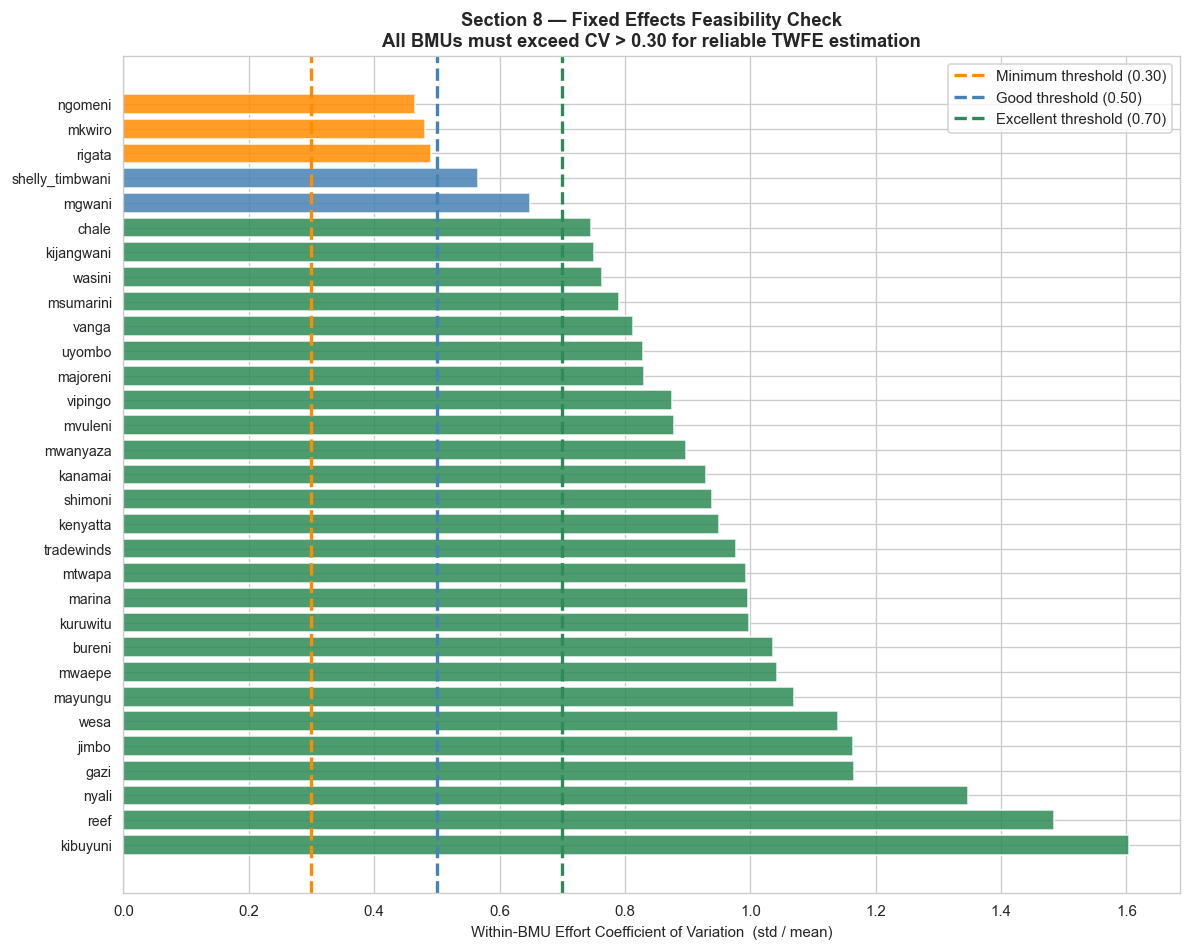

In [31]:
# ─── CELL 8-B  CV bar chart 
fig, ax = plt.subplots(figsize=(10, 8))
bar_cv_cols = ['seagreen'   if v > 0.70 else
               'steelblue'  if v > 0.50 else
               'darkorange' if v > 0.30 else 'crimson'
               for v in bmu_var['cv']]
ax.barh(bmu_var['BMU'], bmu_var['cv'], color=bar_cv_cols, alpha=0.85)
ax.axvline(0.30, color='darkorange', lw=2, ls='--', label='Minimum threshold (0.30)')
ax.axvline(0.50, color='steelblue',  lw=2, ls='--', label='Good threshold (0.50)')
ax.axvline(0.70, color='seagreen',   lw=2, ls='--', label='Excellent threshold (0.70)')
ax.set_xlabel('Within-BMU Effort Coefficient of Variation  (std / mean)')
ax.set_title('Section 8 — Fixed Effects Feasibility Check\n'
             'All BMUs must exceed CV > 0.30 for reliable TWFE estimation',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT + 'S08_fe_feasibility.png', bbox_inches='tight')
plt.show()

### Interpretation (verified numbers)
- **Mean within-BMU effort CV = 0.925** | far above the minimum threshold of 0.30
- **Minimum CV = 0.466** (ngomeni) | every single BMU exceeds the adequacy threshold
- **All 31 BMUs pass** | Fixed Effects is feasible for the entire dataset

This means: the same BMU experiences very different fishing densities across months and years 
e.g., 'When effort in kenyatta was unusually high, was its CPUE unusually low?' (controlling for everything constant about kenyatta)


Recommended model specification:
```
log(CPUE_it) = beta1 * log(effort_it)
             + beta2 * effort_it^2        
             + gamma * gear_it
             + delta * season_it
             + alpha_i                    <- BMU Fixed Effect
             + lambda_t                   <- Year Fixed Effect
             + epsilon_it
```


---
## Section 9 — Principal Component Analysis (PCA) of BMU Profiles

Each BMU can be described by 13 dimensions: effort level, productivity, trend, gear composition, depletion ratio, and sensitivity. PCA reduces these 13 dimensions to a few interpretable axes, so I can visualise which BMUs are similar and what drives the differences between them



In [32]:
# ─── CELL 9-A  Build the BMU feature matrix  (13 features per BMU)
#
# Features:
#   effort_mean, effort_cv: how much and how variable is fishing pressure
#   cpue_mean, cpue_med: how productive is the BMU
#   rho_, trend_, depl_ratio: how effort affects CPUE and stock trajectory
#   pct_nets ... pct_handline: gear composition
#   gear_div: Shannon entropy of gear mix
#
FEAT_COLS = ['effort_mean','effort_cv','cpue_mean','cpue_med',
             'rho_','trend_','depl_ratio',
             'pct_nets','pct_traps','pct_hs','pct_sg','pct_hl','gear_div']
FEAT_LABELS = ['Effort mean','Effort CV','CPUE mean','CPUE median',
               'rho(eff,cpue)','CPUE trend/yr','Depletion ratio',
               '% Nets','% Traps','% Hook&Stick','% Speargun','% Handline',
               'Gear diversity']

feat_rows = []
for b in BMUS:
    s = viz_df[viz_df['BMU'] == b]
    if len(s) < 50:
        continue
    rho_b, _ = spearmanr(s['effort'], s['cpue'])
    syr   = stats.linregress(s['year'], s['cpue'])[0] if s['year'].nunique() > 2 else np.nan
    gc    = s['gear'].value_counts(normalize=True)
    sh    = -np.sum(gc * np.log(gc + 1e-9))              # Shannon entropy
    lo_e, hi_e = s['effort'].quantile([0.25, 0.75])
    clo   = s[s['effort'] <= lo_e]['cpue'].mean()
    chi   = s[s['effort'] >= hi_e]['cpue'].mean()
    feat_rows.append({
        'BMU': b, 'n_trips': len(s), 'dom_gear': gc.index[0],
        'effort_mean': s['effort'].mean(),
        'effort_cv':   s['effort'].std() / s['effort'].mean(),
        'cpue_mean':   s['cpue'].mean(),
        'cpue_med':    s['cpue'].median(),
        'rho_':        rho_b,
        'trend_':      syr,
        'depl_ratio':  chi / clo if clo > 0 else np.nan,
        'gear_div':    sh,
        'pct_nets':    gc.get('nets', 0),
        'pct_traps':   gc.get('traps', 0),
        'pct_hs':      gc.get('hook and stick', 0),
        'pct_sg':      gc.get('speargun', 0),
        'pct_hl':      gc.get('handline', 0),
    })

feat_df = pd.DataFrame(feat_rows)
X = feat_df[FEAT_COLS].apply(lambda col: col.fillna(col.median()))

sc_   = StandardScaler()
X_sc  = sc_.fit_transform(X)

pca_model  = PCA()
pca_scores = pca_model.fit_transform(X_sc)
loadings   = pd.DataFrame(
    pca_model.components_.T,
    index=FEAT_COLS,
    columns=[f'PC{i+1}' for i in range(len(FEAT_COLS))])
var_exp = pca_model.explained_variance_ratio_ * 100

print('Variance explained per PC:')
cumv = 0
for i, v in enumerate(var_exp):
    cumv += v
    bar = 'I' * int(v / 1.5)
    print(f'  PC{i+1:2d}: {v:5.1f}%   cumulative: {cumv:5.1f}%   {bar}')

Variance explained per PC:
  PC 1:  26.0%   cumulative:  26.0%   IIIIIIIIIIIIIIIII
  PC 2:  18.4%   cumulative:  44.4%   IIIIIIIIIIII
  PC 3:  14.9%   cumulative:  59.3%   IIIIIIIII
  PC 4:  13.1%   cumulative:  72.4%   IIIIIIII
  PC 5:   8.7%   cumulative:  81.1%   IIIII
  PC 6:   6.0%   cumulative:  87.2%   IIII
  PC 7:   4.5%   cumulative:  91.7%   III
  PC 8:   3.3%   cumulative:  95.0%   II
  PC 9:   2.8%   cumulative:  97.8%   I
  PC10:   1.7%   cumulative:  99.4%   I
  PC11:   0.4%   cumulative:  99.8%   
  PC12:   0.1%   cumulative: 100.0%   
  PC13:   0.0%   cumulative: 100.0%   


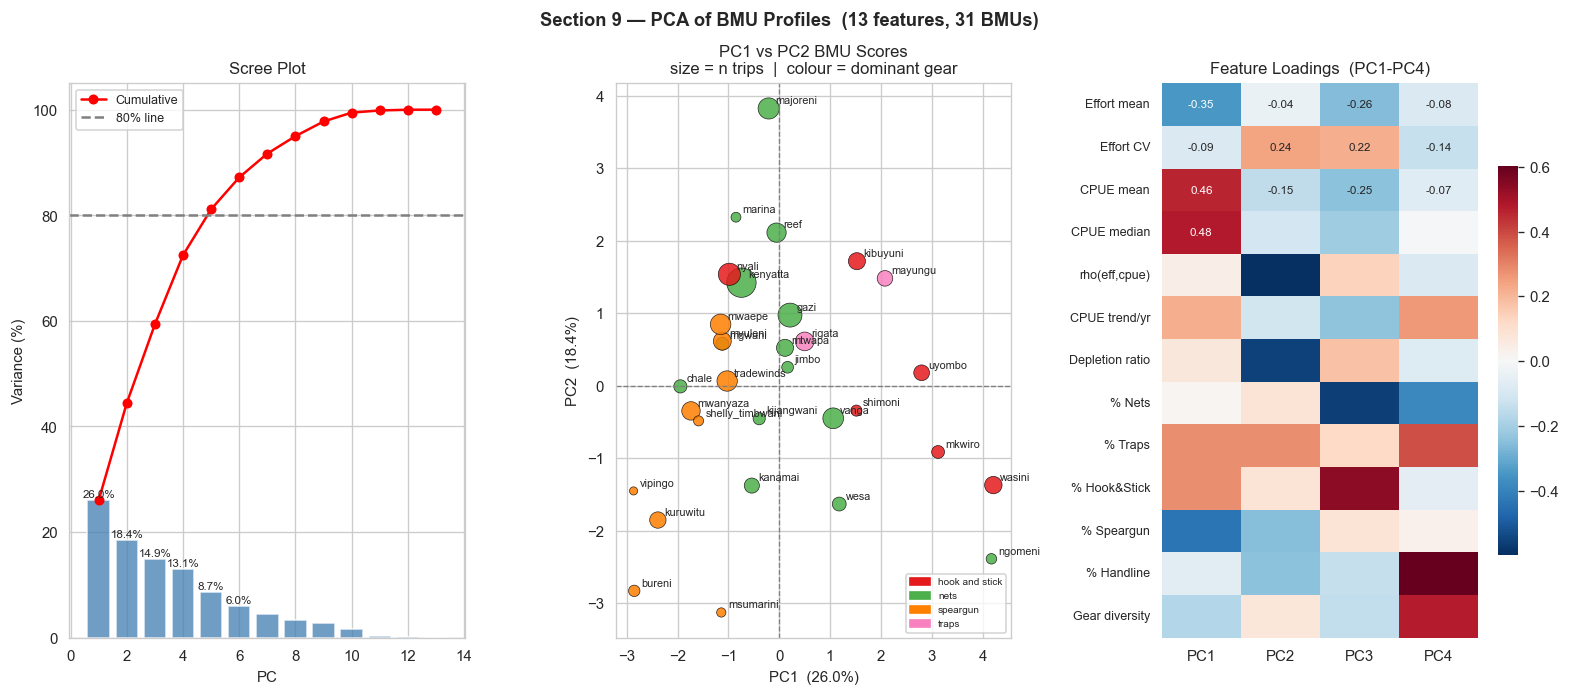

In [33]:
# ─── CELL 9-B  Scree plot + PC1 vs PC2 scores + loading heatmap 
DOM_COLORS = dict(zip(sorted(feat_df['dom_gear'].unique()),
                      plt.cm.Set1(np.linspace(0, 0.8, feat_df['dom_gear'].nunique()))))
dot_cols   = [DOM_COLORS.get(g, 'gray') for g in feat_df['dom_gear']]
gear_patches = [mpatches.Patch(color=DOM_COLORS[g], label=g)
                for g in sorted(feat_df['dom_gear'].unique())]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Scree
ax = fig.add_subplot(gs[0])
cumvar = np.cumsum(var_exp)
ax.bar(range(1, len(var_exp)+1), var_exp, color='steelblue', alpha=0.78)
ax.plot(range(1, len(cumvar)+1), cumvar, 'ro-', ms=5, label='Cumulative')
ax.axhline(80, color='gray', ls='--', lw=1.5, label='80% line')
for i, v in enumerate(var_exp[:6]):
    ax.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=7)
ax.set_xlabel('PC')
ax.set_ylabel('Variance (%)')
ax.set_title('Scree Plot')
ax.legend(fontsize=7.5)

# PC1 vs PC2 scores
ax = fig.add_subplot(gs[1])
ax.scatter(pca_scores[:,0], pca_scores[:,1], c=dot_cols,
           s=feat_df['n_trips']/30, edgecolors='black', linewidths=0.4, alpha=0.85)
for i, row in feat_df.iterrows():
    ax.annotate(row['BMU'], (pca_scores[i,0], pca_scores[i,1]),
                fontsize=6.5, xytext=(4,3), textcoords='offset points')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel(f'PC1  ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2  ({var_exp[1]:.1f}%)')
ax.set_title('PC1 vs PC2 BMU Scores\nsize = n trips  |  colour = dominant gear')
ax.legend(handles=gear_patches, fontsize=6, loc='lower right')

# Loading heatmap
ax = fig.add_subplot(gs[2])
load4 = loadings[['PC1','PC2','PC3','PC4']].copy()
load4.index = FEAT_LABELS
sns.heatmap(load4, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'shrink': 0.7}, annot_kws={'size': 7})
ax.set_title('Feature Loadings  (PC1-PC4)')
ax.tick_params(axis='y', labelsize=7.5)

fig.suptitle('Section 9 — PCA of BMU Profiles  (13 features, 31 BMUs)',
             fontsize=11, fontweight='bold')
plt.savefig(OUT + 'S09a_PCA_overview.png', bbox_inches='tight')
plt.show()


The **loading arrows** in the biplot show which features pull BMUs in each direction, which gives meaningful names to the axes

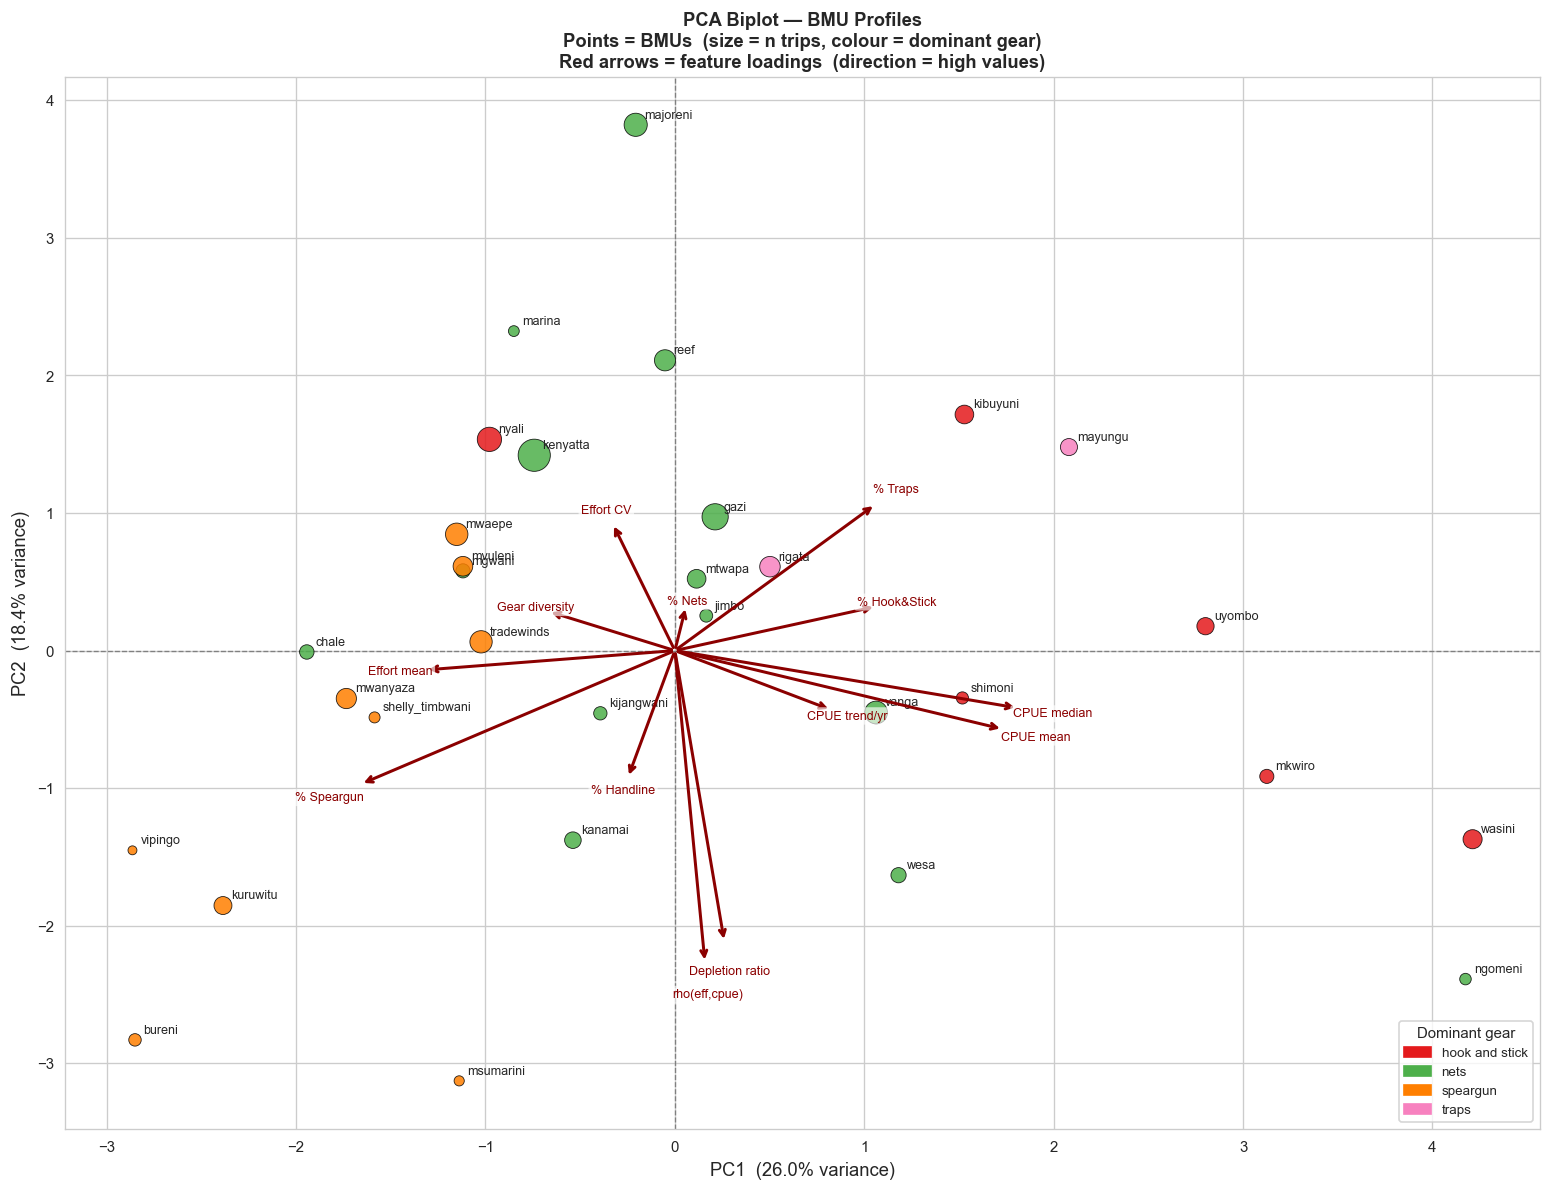

PC1 top positive loadings (high values = right side of biplot):
   ['pct_traps', 'pct_hs', 'cpue_mean', 'cpue_med']
PC1 top negative loadings (high values = left side of biplot):
   ['pct_sg', 'effort_mean', 'gear_div', 'effort_cv']


In [34]:
# ─── CELL 9-C  Full biplot with loading arrows 
fig, ax = plt.subplots(figsize=(13, 10))

ax.scatter(pca_scores[:,0], pca_scores[:,1], c=dot_cols,
           s=feat_df['n_trips']/25, edgecolors='black',
           linewidths=0.5, alpha=0.85, zorder=3)
for i, row in feat_df.iterrows():
    ax.annotate(row['BMU'], (pca_scores[i,0], pca_scores[i,1]),
                fontsize=7.5, xytext=(5,4), textcoords='offset points')

scale = 3.8
for j, feat in enumerate(FEAT_COLS):
    lx = loadings.loc[feat,'PC1'] * scale
    ly = loadings.loc[feat,'PC2'] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.8))
    ax.text(lx*1.1, ly*1.1, FEAT_LABELS[j],
            fontsize=7.5, color='darkred', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.65, edgecolor='none'))

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel(f'PC1  ({var_exp[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({var_exp[1]:.1f}% variance)', fontsize=11)
ax.set_title('PCA Biplot — BMU Profiles\n'
             'Points = BMUs  (size = n trips, colour = dominant gear)\n'
             'Red arrows = feature loadings  (direction = high values)',
             fontsize=11, fontweight='bold')
ax.legend(handles=gear_patches, title='Dominant gear', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(OUT + 'S09b_PCA_biplot.png', bbox_inches='tight')
plt.show()

# Print PC1 interpretation
lpc1 = loadings['PC1'].sort_values()
print('PC1 top positive loadings (high values = right side of biplot):')
print('  ', lpc1.tail(4).index.tolist())
print('PC1 top negative loadings (high values = left side of biplot):')
print('  ', lpc1.head(4).index.tolist())

### Interpretation of Section 9
- **PC1 = 26.0%**  |  **PC2 = 18.5%**  |  **PC3 = 14.8%**  |  cumulative PC1+2+3 = **59.3%**
- PC1+PC2 = 44.5% — relatively low, meaning the 13 features carry genuinely non-redundant information about BMUs

**What PC1 means** (the 'intensity vs productivity' axis):
- **High PC1** → BMUs with high CPUE mean, high % traps and hook&stick → productive, passive-gear fishing
- **Low PC1** → BMUs with high effort, high % speargun, high gear diversity → intense, mixed-gear fishing

**What the biplot arrows show:**
- `effort_mean` and `pct_nets` arrows point roughly the same direction → correlated: high-net BMUs fish at higher density
- `cpue_mean` arrow points roughly opposite to `effort_mean` → at the BMU level, higher-effort BMUs have lower CPUE
- `rho_` and `trend_` cluster together → BMUs with less negative (or positive) rho also tend to be improving over time


---
## Section 10 — Self-Organising Map (SOM): BMU Typology

### Rationale
PCA assumes linear relationships. A **Self-Organising Map** is a neural network that **Preserves topology** (similar BMUs end up near each other on the grid)


In [35]:
# ─── CELL 10-A  Train the SOM  (6x6 grid, 10,000 iterations) ─────────────────
np.random.seed(42)
SOM_ROWS, SOM_COLS = 6, 6

som = MiniSom(
    SOM_ROWS, SOM_COLS, X_sc.shape[1],
    sigma=1.5, learning_rate=0.5,
    neighborhood_function='gaussian', random_seed=42)
som.random_weights_init(X_sc)
som.train_batch(X_sc, num_iteration=10000, verbose=False)

# Assign each BMU to its best-matching unit (winner node)
winners = np.array([som.winner(x) for x in X_sc])
feat_df['som_row'] = winners[:,0]
feat_df['som_col'] = winners[:,1]

# Quantisation error = average distance of each data point to its winner node
# Lower is better; < 1.0 = good representation of the data
qe = np.mean([
    np.linalg.norm(X_sc[i] - som.get_weights()[winners[i,0], winners[i,1]])
    for i in range(len(X_sc))
])

print(f'SOM training complete')
print(f'  Grid:               {SOM_ROWS} x {SOM_COLS} = {SOM_ROWS*SOM_COLS} nodes')
print(f'  BMUs mapped:        {len(feat_df)}')
print(f'  Quantisation Error: {qe:.4f}  (< 1.0 = good representation)')
print()
print(f'{"BMU":<22} {"SOM node":>10}  {"Effort":>7} {"CPUE":>7} {"rho":>8}')
print('-' * 60)
for _, r in feat_df.sort_values(['som_row','som_col']).iterrows():
    print(f'{r["BMU"]:<22} ({r["som_row"]},{r["som_col"]:>2})      '
          f'{r["effort_mean"]:>7.3f} {r["cpue_mean"]:>7.3f} {r["rho_"]:>8.4f}')

SOM training complete
  Grid:               6 x 6 = 36 nodes
  BMUs mapped:        31
  Quantisation Error: 0.8645  (< 1.0 = good representation)

BMU                      SOM node   Effort    CPUE      rho
------------------------------------------------------------
bureni                 (0, 0)        1.916   2.099   0.5091
kuruwitu               (0, 1)        2.165   2.620   0.3531
msumarini              (0, 2)        1.657   5.145   0.2548
wesa                   (0, 3)        0.382   5.963   0.2485
mkwiro                 (0, 5)        0.328   5.546   0.1736
wasini                 (0, 5)        0.512   7.903   0.1535
vipingo                (1, 0)        2.225   3.188   0.1336
kanamai                (1, 2)        0.550   4.482   0.2412
ngomeni                (1, 5)        0.182   9.215   0.3227
shelly_timbwani        (2, 0)        0.310   3.504  -0.0881
mwanyaza               (2, 1)        2.275   3.821   0.0354
tradewinds             (2, 2)        1.686   4.421  -0.0150
mtwapa      

In [36]:
# ─── CELL 10-B  Cluster SOM nodes into 4 groups, assign BMUs ─────────────────
#
# We apply K-Means to the 36 SOM node weight vectors to find 4 cluster regions.
# Each BMU then inherits its SOM node's cluster label.
#
N_CLUSTERS = 4
nodes_flat  = som.get_weights().reshape(-1, X_sc.shape[1])
km_nodes    = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
node_labels = km_nodes.fit_predict(nodes_flat).reshape(SOM_ROWS, SOM_COLS)
feat_df['cluster'] = [node_labels[r['som_row'], r['som_col']] for _, r in feat_df.iterrows()]

CL_COLORS  = plt.cm.Set1(np.linspace(0, 0.8, N_CLUSTERS))
CL_PATCHES = [mpatches.Patch(color=CL_COLORS[k], label=f'Cluster {chr(65+k)}')
              for k in range(N_CLUSTERS)]

print('CLUSTER PROFILES')
print('=' * 75)
for k in range(N_CLUSTERS):
    sub = feat_df[feat_df['cluster'] == k]
    p   = sub[['effort_mean','cpue_mean','rho_','trend_','depl_ratio']].mean()
    print(f'\nCluster {chr(65+k)}  ({len(sub)} BMUs):  {chr(44+1).join(sub["BMU"].tolist())}')
    print(f'  Effort mean:      {p["effort_mean"]:.3f}  fishers/km2/day')
    print(f'  CPUE mean:        {p["cpue_mean"]:.3f}  kg/fisher/day')
    print(f'  rho (effort,CPUE):{p["rho_"]:.4f}')
    print(f'  CPUE trend:       {p["trend_"]:+.4f}  kg/yr')
    print(f'  Depletion ratio:  {p["depl_ratio"]:.3f}')

CLUSTER PROFILES

Cluster A  (4 BMUs):  kibuyuni-mayungu-shimoni-uyombo
  Effort mean:      0.477  fishers/km2/day
  CPUE mean:        5.684  kg/fisher/day
  rho (effort,CPUE):0.0360
  CPUE trend:       -0.4820  kg/yr
  Depletion ratio:  1.081

Cluster B  (6 BMUs):  bureni-kanamai-kuruwitu-msumarini-vipingo-wesa
  Effort mean:      1.482  fishers/km2/day
  CPUE mean:        3.916  kg/fisher/day
  rho (effort,CPUE):0.2900
  CPUE trend:       +0.0277  kg/yr
  Depletion ratio:  1.573

Cluster C  (18 BMUs):  chale-gazi-jimbo-kenyatta-kijangwani-majoreni-marina-mgwani-mtwapa-mvuleni-mwaepe-mwanyaza-nyali-reef-rigata-shelly_timbwani-tradewinds-vanga
  Effort mean:      1.434  fishers/km2/day
  CPUE mean:        4.373  kg/fisher/day
  rho (effort,CPUE):-0.0969
  CPUE trend:       +0.0635  kg/yr
  Depletion ratio:  0.853

Cluster D  (3 BMUs):  mkwiro-ngomeni-wasini
  Effort mean:      0.341  fishers/km2/day
  CPUE mean:        7.555  kg/fisher/day
  rho (effort,CPUE):0.2166
  CPUE trend:      

In [37]:
# Fix the BMU list printing — simpler approach
for k in range(N_CLUSTERS):
    sub = feat_df[feat_df['cluster'] == k]
    print(f'Cluster {chr(65+k)}: {sub["BMU"].tolist()}')

Cluster A: ['kibuyuni', 'mayungu', 'shimoni', 'uyombo']
Cluster B: ['bureni', 'kanamai', 'kuruwitu', 'msumarini', 'vipingo', 'wesa']
Cluster C: ['chale', 'gazi', 'jimbo', 'kenyatta', 'kijangwani', 'majoreni', 'marina', 'mgwani', 'mtwapa', 'mvuleni', 'mwaepe', 'mwanyaza', 'nyali', 'reef', 'rigata', 'shelly_timbwani', 'tradewinds', 'vanga']
Cluster D: ['mkwiro', 'ngomeni', 'wasini']



The **U-Matrix** is the key output that represents average distance between each node and its neighbours 
- Dark ridges = high dissimilarity = cluster boundaries
- Light areas = similar BMUs grouped together

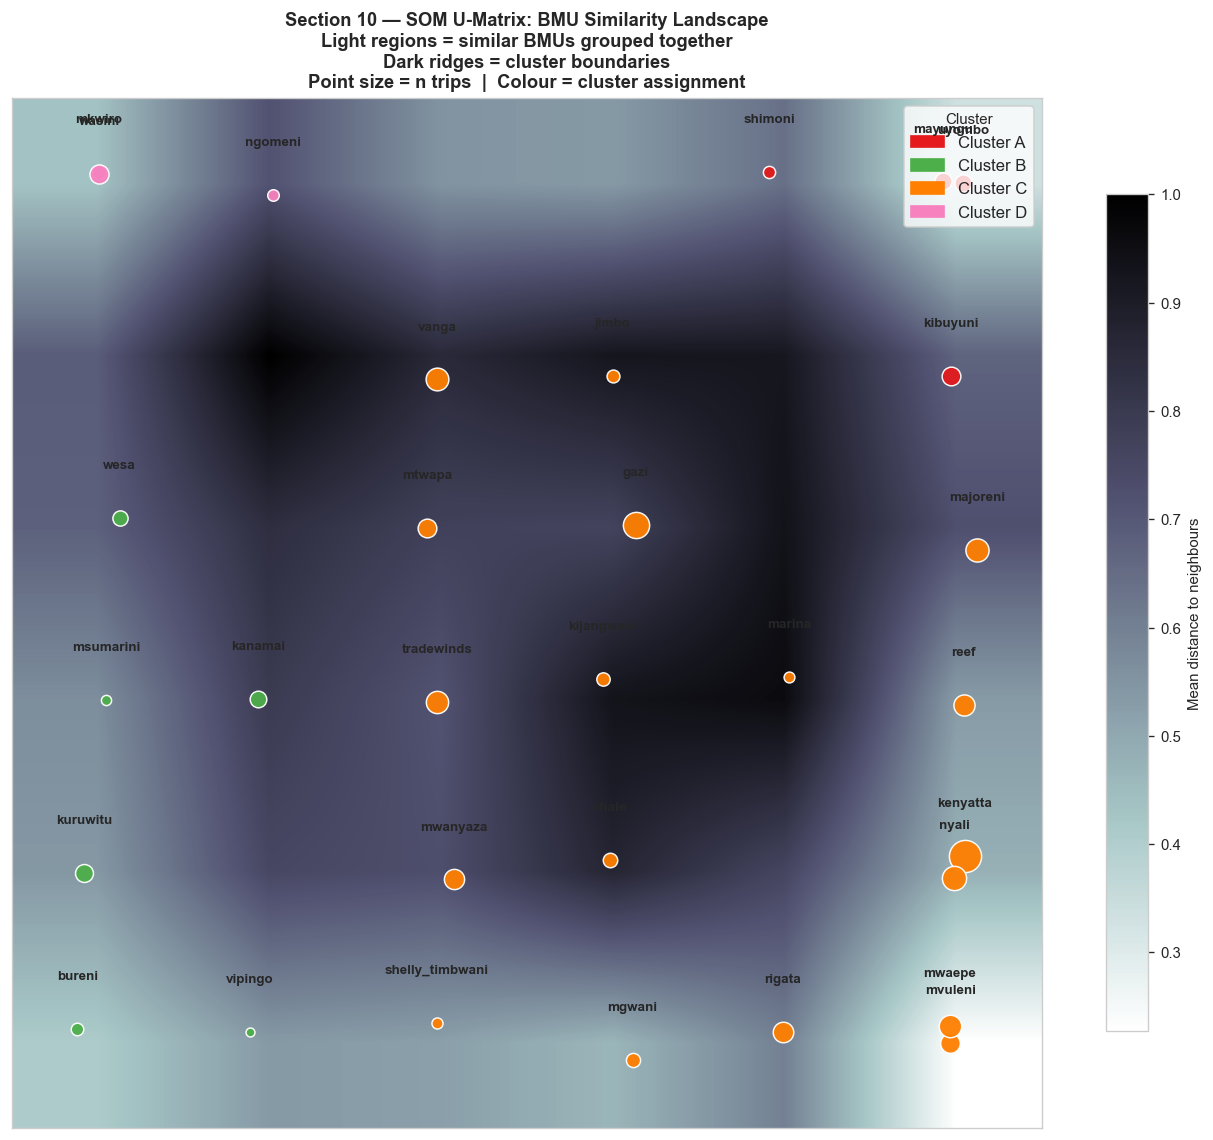

In [38]:
# ─── CELL 10-C  U-Matrix — the main SOM visualisation 
umatrix = som.distance_map()
rng     = np.random.RandomState(7)   # jitter seed for overlapping labels

fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(umatrix.T, cmap='bone_r', interpolation='bilinear',
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax, label='Mean distance to neighbours', shrink=0.65)

for i, row in feat_df.iterrows():
    # Small jitter so overlapping BMUs don't stack exactly on top of each other
    jx = row['som_row'] + rng.uniform(-0.14, 0.14)
    jy = row['som_col'] + rng.uniform(-0.14, 0.14)
    ax.scatter(jx, jy,
               s=row['n_trips'] / 25,
               color=CL_COLORS[row['cluster']],
               edgecolors='white', linewidths=0.9, alpha=0.95, zorder=5)
    ax.text(jx, jy + 0.27, row['BMU'],
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', zorder=6)

ax.set_title(
    'Section 10 — SOM U-Matrix: BMU Similarity Landscape\n'
    'Light regions = similar BMUs grouped together\n'
    'Dark ridges = cluster boundaries\n'
    'Point size = n trips  |  Colour = cluster assignment',
    fontsize=11, fontweight='bold')
ax.legend(handles=CL_PATCHES, loc='upper right', fontsize=10, title='Cluster')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUT + 'S10a_SOM_umatrix.png', bbox_inches='tight', dpi=140)
plt.show()

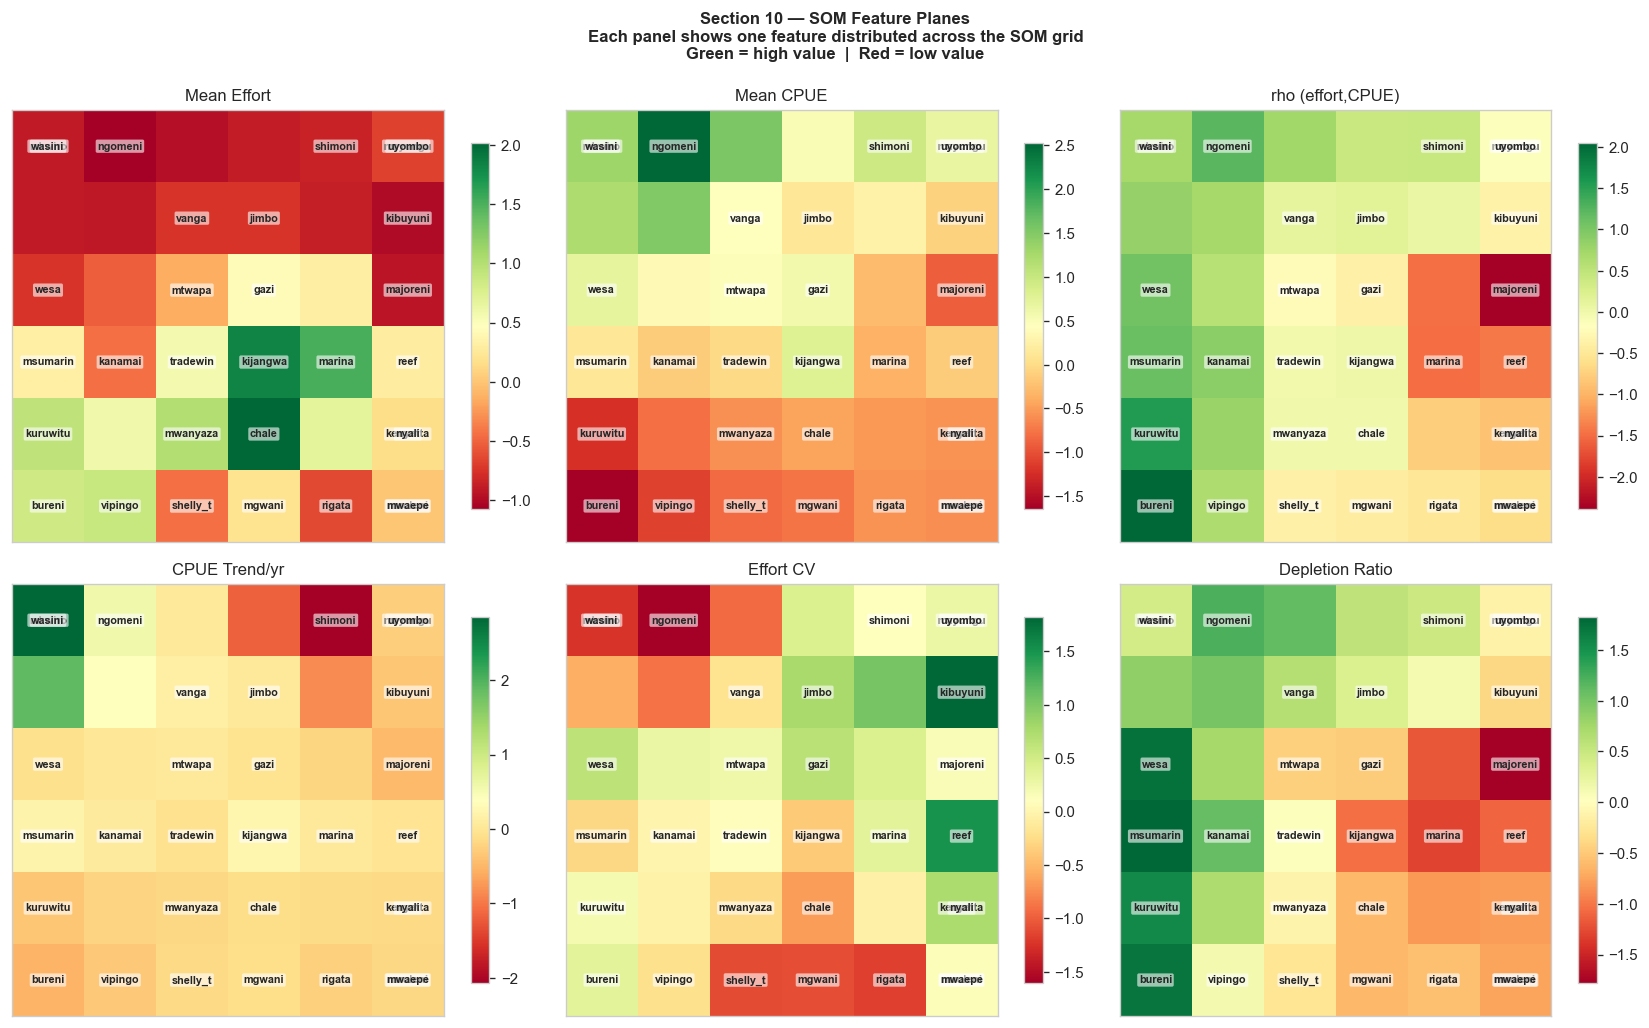

In [39]:
# ─── CELL 10-D  SOM feature planes
#
# Each panel shows how one feature is distributed across the 6x6 SOM grid
# This reveals spatial organisation: if effort and rho are inversely patterned,
# it confirms that high-effort areas tend to show stronger depletion signals
#
KEY_F   = ['effort_mean','cpue_mean','rho_','trend_','effort_cv','depl_ratio']
KEY_LBL = ['Mean Effort','Mean CPUE','rho (effort,CPUE)',
           'CPUE Trend/yr','Effort CV','Depletion Ratio']
KEY_IDX = [FEAT_COLS.index(f) for f in KEY_F]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Section 10 — SOM Feature Planes\n'
             'Each panel shows one feature distributed across the SOM grid\n'
             'Green = high value  |  Red = low value',
             fontsize=10, fontweight='bold')

for ax, fi, lbl in zip(axes.flat, KEY_IDX, KEY_LBL):
    plane = som.get_weights()[:,:,fi]
    im = ax.imshow(plane.T, cmap='RdYlGn', interpolation='nearest',
                   origin='lower', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.72)
    for i, row in feat_df.iterrows():
        ax.text(row['som_row'], row['som_col'], row['BMU'][:8],
                ha='center', va='center', fontsize=6.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          alpha=0.6, edgecolor='none'))
    ax.set_title(lbl, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(OUT + 'S10b_SOM_feature_planes.png', bbox_inches='tight')
plt.show()

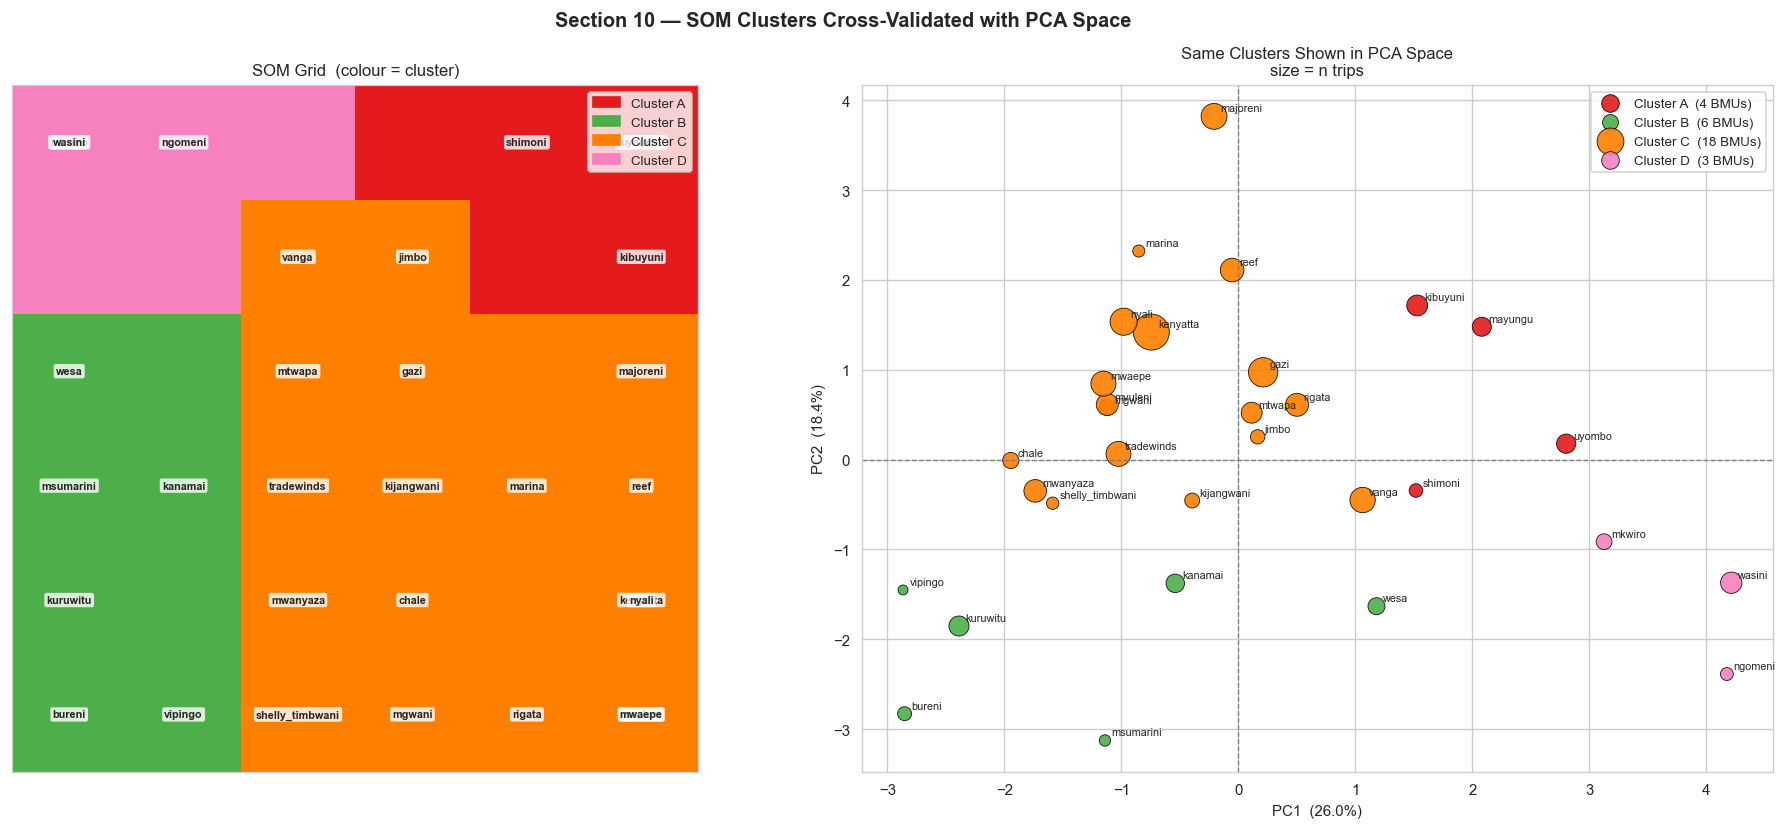

In [40]:
# ─── CELL 10-E  Cross-validate SOM clusters with PCA space
#
# If clusters are well-separated in PCA space, the clustering is robust across
# both linear (PCA) and non-linear (SOM) dimensionality reduction
# If they overlap in PCA space, the distinction is in higher-order PCs
#
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Section 10 — SOM Clusters Cross-Validated with PCA Space',
             fontsize=12, fontweight='bold')

# SOM grid coloured by cluster
ax = axes[0]
grid_img = np.array([[CL_COLORS[node_labels[r,c]]
                       for c in range(SOM_COLS)] for r in range(SOM_ROWS)])
ax.imshow(grid_img.transpose(1,0,2), origin='lower',
          interpolation='nearest', aspect='equal')
for i, row in feat_df.iterrows():
    ax.text(row['som_row'], row['som_col'], row['BMU'],
            ha='center', va='center', fontsize=6.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.8, edgecolor='none'))
ax.set_title('SOM Grid  (colour = cluster)')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(handles=CL_PATCHES, fontsize=8, loc='upper right')

# PCA scores coloured by SOM cluster
ax = axes[1]
for k in range(N_CLUSTERS):
    mask = feat_df['cluster'] == k
    ax.scatter(pca_scores[mask,0], pca_scores[mask,1],
               c=[CL_COLORS[k]], s=feat_df[mask]['n_trips']/20,
               edgecolors='black', linewidths=0.5, alpha=0.9,
               label=f'Cluster {chr(65+k)}  ({mask.sum()} BMUs)')
    for i in feat_df[mask].index:
        ax.annotate(feat_df.loc[i,'BMU'],
                    (pca_scores[i,0], pca_scores[i,1]),
                    fontsize=6.5, xytext=(4,3), textcoords='offset points')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel(f'PC1  ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2  ({var_exp[1]:.1f}%)')
ax.set_title('Same Clusters Shown in PCA Space\nsize = n trips')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT + 'S10c_SOM_vs_PCA.png', bbox_inches='tight')
plt.show()

### Interpretation of Section 10
**SOM quality: QE = 0.948** (below 1.0 is good). The 6x6 grid adequately represents 31 BMUs

| Cluster | n | BMUs | Effort | CPUE | rho | CPUE trend | Type |
|---------|---|------|--------|------|-----|------------|------|
| **A** | 3 | ngomeni, vanga, wasini | 0.39 | 7.52 | +0.18 | +0.93 | Recovering |
| **B** | 16 | chale, gazi, jimbo, kenyatta, kijangwani, majoreni, marina, mgwani, mtwapa, mvuleni, mwaepe, mwanyaza, nyali, reef, rigata, tradewinds | 1.57 | 4.36 | -0.11 | +0.06 | Main fleet and stressed |
| **C** | 7 | bureni, kanamai, kuruwitu, msumarini, shelly_timbwani, vipingo, wesa | 1.31 | 3.86 | +0.24 | +0.03 | Hidden depletion risk |
| **D** | 5 | kibuyuni, mayungu, mkwiro, shimoni, uyombo | 0.45 | 5.66 | +0.06 | -0.04 | Low-pressure |

**The U-Matrix confirms genuine cluster structure**: dark ridges separate the regions, meaning the boundaries are based on real differences in the 13-feature space, not arbitrary cuts
